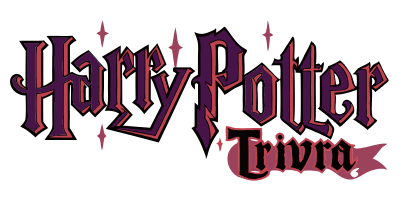

<div style="background-color: #f0e6f7; padding: 10px;">
    <h2 style="text-align:center; color:purple;">Harry Potter Trivia Game</h2>
    <h3 style="text-align:center; color:purple;">Using Gen AI to create new trivia questions</h3>
</div>

# 1: Introduction
The goal of this project is to create an engaging Harry Potter trivia game that is more intuitive and flexible than typical multiple-choice formats found online. It will leverage Natural Language Processing (NLP) to handle fluid, free-text player responses, for a more intuitive, interactive, and engaging experience for the player. This capability for flexible answer checking is a key differentiator to game formats commonly available for fans. 

in this notebook, LLM models will be used to generate new trivia questions with the following aims:

1. **Balance the current Baseline dataset**: In the [previous EDA notebook](../02_eda_and_deduplication.ipynb), two key imbalances were identified within the baseline (v1) dataset. Nearly 80% of the questions are straight fowards Factual Recall (FR) types with short answers (1-3 words), and many are sourced from auxiliary content rather than the core seven books. To create a more varied and engaging gameplay experience, we need to address these gaps. Adding more Explanatory (EX) questions is a top priority, as they are more thought-provoking, creating a richer experience for fans that enjoy deep lore. It also creates the perfect opportunity to implement semantic answer checking. Increasing the number of Multiple-Choice (MCQ) and Factual Recall (FR)) questions will also be crucial for managing difficulty within a game session.

2. **Train the SentenceBERT model with domain specific terminology**: Because these questions are being generated from scratch, the LLMs can produce variations in answers to each question to help train the model to recognize variability from a Player's answers. The questions and answers should also richly represent the Harry Potter specific terminology and correctly based on lore.

### Scope of the notebook

This notebook focuses on using a Large Language Model (LLM) to generate a new, balanced set of questions. The process will cover three main stages:

- **Define the prompt engineering strategy**: Outline the key decisions, scope, constraints, and overall approach to consider when generating the new questions.
- **Develop and Test the master prompt**: Iteratively create and test a prompt script for different question types (EX, MCQ, etc.) to achieve the desired quality of questions.
- **Finalize the generation script**: Create the final, validated Python script that will be used to generate the full batch of new questions for the dataset.

# Table of Contents

1. [**Introduction**](#1-introduction)
2. [**Glossary of key terms**](#2-glossary-of-key-terms)
3. [**Setup and imports**](#3-setup-and-imports)
4. [**Prompt engineering strategy**](#4-prompt-engineering-strategy)<br>
    4.1. [Key decisions](#41-key-decisions)<br>
    4.2. [Scope limits and constraints](#42-scope-limits-and-constraints)<br>
    4.3. [Approach](#43-approach)<br>
    4.4. [Master prompt](#44-master-prompt)<br>
    4.5. [Source text preparation](#45-source-text-preparation)<br>
    4.6. [Script for generating questions](#45-script-for-generating-questions)<br>
5. [**Experimentation**](#5-experimentation)<br>
    5.1. [Source text for testing](#51-source-text-for-testing)<br>
    5.2. [Explanatory (EX) questions](#52-explanatory-ex-questions)<br>
    5.3. [Multiple-Choice questions (MCQ)](#53-mulitple-choice-questions-mcq)<br>
    5.4. [Yes/No (YN) questions](#54-yes--no-yn-questions)<br>
    5.5. [Factual Recall (FR) questions](#55-factual-recall-fr-questions)<br>
    5.6. [Full script test](#56-full-script-test) 
6. [Summary](#6-summary)
7. [References](#7-references) 

# 2: Glossary of key terms

To ensure clarity and consistency, the following terms are defined within the context of this analysis:

|Term | Abbreviation | Description|
|-|-|-|
|Natural Language Processing|NLP|A field of AI that enables computers to understand, analyze, and generate human-language|
|Large Language Model|LLM| A type of AI model trained on large amounts of text to understand, generate, and analyze human language|
|Question| Q | A trivia question in the dataset|
|Answer|A| An answer to a trivia question in the dataset|
|Factual Recall (Question) | FR | Question seeking specific objective info (name, date, place, etc.). Identified by keywords such as 'What', 'Who', etc. |
| Explanatory|EX| Question seeking explanation, opinion, or procedure, often identified by keywords like 'Why' or 'How'.|
| Multiple-Choice Question| MCQ| A question that provides options for answers to select from|
| Yes / No (Question)| YN| Questions that elicit set responses such as yes, no, true, false|
| Question Type| QT | Classification assigned (e.g., Factual-Recall, Open-Ended) based primarily on keywords/phrasing, answer type |
| Question Keyword | QK | Lemmatized token from question text used for analysis/filtering (standard stopwords removed, interrogatives kept). |
| MVP of game| CLI-MVP | The first phase prototype of the Harry Potter Trivia game (Command Line Interface - Minimum Viable Product) |
| Quality Assurance | QA | methods and schemes developed to assess the quality of the dataset|  

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

# 3: Setup and imports

First, let's import the necessary external packages as well as internal project environment configuration and custom helper and utility methods from project modules.

In [1]:
#  STANDARD NOTEBOOK SETUP
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../..')
# --- Core Libraries ---
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# --- Project-Specific Imports ---
import notebook_config as nb_cfg
from ds_utils import eda_scripts as eda
from ds_utils import ds_constants as const
# --- Common Settings ---
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 20)

✅ Notebook config loaded.


In [ ]:
# --- Notebook-Specific Imports ---
from collections import OrderedDict
from collections import defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer
from notebook_support.text_processing import tokenize_text, create_sentence_chunks, clean_text_fn
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import nltk
from pathlib import Path
from scripts.research.question_generation.iterations.compile_llm_outputs import compile_selected_runs as csr

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

# 4: Prompt engineering strategy
Instead of jumping right into testing and prompting, we need to develop a high-level strategy to think out the steps and ensure the API calls are efficient, within budget, and deliver high-quality results. This section outlines the scope, key decisions, and overall approach for this task.

## 4.1: Scope, limits, and constraints

In the EDA and processing stage of the baseline dataset, replacements for problematic questions were developed using LLM models. Lessons learned from this initial stage have informed the following criteria for question generation: 

1. **Budget**: The limit to API expenditure is set to $25.00 CAD.

2. **Quality standard**: the generated questions must be:
    - *Factually accurate*: Verifiable against the source text.
    - *Lore-based and within scope*: sourced exclusively from the canon of the specified books.
    - *Formatted properly*: The questions should match the question structures defined for the questions types, EX, MCQ, FR, YN, in the content and source guidelines for [standardizing dataset input](../02_eda_and_deduplication.ipynb).
    - *Non-leading*: phrased to test knowledge without hinting or directing towards the answer.
    - *Varied difficulty*: flag each question with an appropriate difficulty (Easy, Medium Hard).
    - *Sentence-BERT training data*: for the EX and FR types, the output must include 4 distinct, grammatically correct, semantically similar variations of the primary answer. These answers can then be used to train Sentence-BERT for answer checking.
    - *Quality over quantity*: Hard-coding a specific number for the model to extract from each model may push it to generate questions that might be of lower quality to meet the allocated quota in cases where the chapters are sparse. Instead, the model will have discretion to generate fewer questions from sparser chapters, prioritizing quality over a fixed quota.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 4.2: Key decisions
A number of key decisions need to be considered and defined to ensure we achieve the desired criteria from [section 4.1](#41-scope-limits-and-constraints).

### 4.2.1: Overview of decisions

|Decision | Rational & key considerations |Outcome|
|-|-|-|
|Number of questions|The primary goal is to generate a diverse dataset with a strong focus on Explanatory (EX) and Factual-Recall (FR) questions for Sentence-BERT training. An initial high target was revised to prioritize quality over quantity. Also new FR and MCQ questions will help further balance the dataset |250~300 EX, 250~300 FR, ~150 MCQ|
|Source content| The selection is focused on a small number of books to ensure thematic range and a natural story arc progression (beginning, middle, end). Chosen books must be eventful, well-paced, and popular| Books 3,4,7|
|API provider & LLM models|An assessment of free tiers and pay-as-you-go pricing determined that the Google Gemini API is the most practical and cost-effective option for both development and bulk generation.| Google Gemini 2.5 (test between Flash and Pro)|

<details>

<summary><b>🔎 Click to expand: The rational for each decision is provided in the subsections below</b>.</summary>

### 4.2.2: Decision 1 - Source content

To ensure questions are correct, lore-based, and reliable (i.e. minimize hallucinations) they need to be sourced directly from the books themselves. The questions will be sourced from book 3 (*Prisoner of Azkaban*), book 4 (*Goblet of Fire*), and book 7 (*The deathly hallows*). As some of the most popular books in the series [[1]](#7-references), they are likely to be well-known by players. They also represent a reasonable breadth of the saga's content and tone, progressing from the lighter mood of the early books to the darker themes of the finale. These novels are also relatively eventful and well paced through evenly across the chapters, which would make them good content for facts and events to centre questions around. In contrast, book 5 (*Order of the Phoenix*) for example, is mostly Harry's internal diaglogue unitl the final chapters of the book. 

If further content can be explored, book 6 (*The half-blood prince*) can also be considered. 

### 4.2.3: Decision 2 - Number of questions

The baseline dataset needs to be balanced with respect to question type and source content (refer to the [EDA notebook](../02_eda_and_deduplication.ipynb) for details). Currently, the baseline dataset is skewed heavily towards FR type questions, with EX and MCQ. These questions are also predominently from auxilliary sources such *Fantastic beasts and where to find them* and *Quidditch through the ages* which is less known then the main books. 

New questions will be added to address these gaps and to provide robust training data for the answer-checking model. The generation will target:

- **~250-300 EX questions**: This is the top priority, as these questions add the most semantic depth for player engagement and for training the Sentence-BERT answer checker. An initial target of 500 EX, 100 MCQ and 50 FR were considered primarily looking at balancing question type. But this would put mean generating 10 to 12 questions from a chapter. This might push the model to prioritize meeting the quota in sparser chapters, possibly introducing repetitive or lower-quality questions. It would be better to instead focus the prompts on generating a few (4 to 6) high quality explanatory question per chapter, resulting in about 200~250 questions. There is enough room in the budget to rerun the successful prompts to generate more questions from other books, as needed.

- **~250-300 FR questions**: A similar number of FR questions is needed to ensure the answer-checking model is robustly trained on both long-form semantic meaning (from EX answers) and short-form factual accuracy. The planned answer checker will first attempt a simple fuzzy match and if that fails it will fall back to a semantic similarity check. This makes the fine-tuned Sentence-BERT model a critical 'safety net' for factual answers. These questions also add diversity to the FR questions. In the [EDA](../02_eda_and_deduplication.ipynb), it was found that the existing FR question focus heavily on auxilliary content more than the main books.

-**~150 MCQ questions**: This will significantly increase the diversity of question types and improve the gameplay experience.

### 4.2.4: Decision 3 - Selection of LLM model API provider

The selection of an LLM provider was guided by a pragmatic assessment of available free tiers and pay-as-you-go pricing. While several state-of-the-art models were considered, the **Google Gemini API** quickly emerged as the most practical choice for this project's development and execution phases.

#### A. Basis for estimate for API calls

- safety margin = 20%
- Input context: ~14,100 tokens. This is based on two chapters per API call with an mean / median word count of ~5300 per chapter [[2]](#7-references). As per OpenAI guidelines [[3]](#7-references), a general rule of thumb is to consider 100 tokens to be about 75 words. So each chapter would have about 7,049 tokens.
- Input prompt (cached): ~800 tokens. This would be the master prompts, including all instructions, few-shot examples, and formatting rules.
- Output json tokens: ~1800 tokens for explanatory questions (to generate 4~6 high-quality questions with 275~300 token per record). The questions and their answers will be wordier and also have multiple answers to train the Sentence-BERT for answer checking later. ~200~260 tokens for the FR and MCQ questions (to generate ~3 questions). We can an expect ~308 tokens for EX, ~163 for FR, and ~198 tokens for MCQ for one output question 
- Number of API calls required for all three question types: 
    - number of chapters: 22 (book 3) + 37 (book 4) + 37 (book 7) = 96 
    - number of calls per question type = 48
    - total number of API calls for EX, FR, MCQ: 144

So based on this we can establish the following cost parameters:
|**Total Input tokens (context)**| **Total input tokens cached (prompt)**| **Output tokens**|
|-|-|-|
|2.03 M| 0.115 M | 0.142 M|

#### B. Free-tier access 
The most ideal approach would be to carry out the analysis within the free-tiers of the providers. This method will be used for testing and experimenting and will also be explored for the batch generation. 

Currently only Google offers a direct access free-tier. Open AI no longer does and DeepSeek requires a pre-paid credit ($5 minimum). DeepSeek can be accessed as a free-tier through third parties (e.g. OpenRouter, Nvidia NIM APIs) but that would require familiarizing with a new platform. As such Google API is the best way forawrd within this tier and an analysis shows this is feasible with several Gemini models:

|Provider|Model| Rate limit<br> (calls per min)|Rate limit <br> (calls per day)|Token limits <br> (per min)| Daily call limit (RPD)| Safe delay <br> times | **Estimated run <br> times** (144 calls)| Reference|
|-|-|-|-|-|-|-|-|-|
|Google | Gemini 2.0 Flash| 15 | 200 | 1,000,000| 200 |5s | **~12 mins**| [[4]](#7-references)| 
|Google | Gemini 2.5 Flash| 10 | 250| 250,000| 250 | 7s| **~17 mins** | [[4]](#7-references)| 
|Google | Gemini 2.5 Pro (flagship)| 2 | 50| 125,000|50|31s| **~25 mins** (over 3 days) |[[4]](#7-references)|

The cost determining factor between the all three rate limits is the **Rate Per Minute (RPM)**, which can be handled by adding a safe delay between API calls in the generation script. This can be illustrated by Looking at the most restrictive option (Gemini 2.5 pro). One API call will have ~15,000 tokens. With a RPM of 2, we would be sending a total of 30,000 tokens in a minute (36,000 with the safety margin). The token counts are below the 125,000 limit. The total calls we need to make are a 144, which would mean we can split the calls over three days since the daily limit is 50 calls (not necessary for the other two models).  If the testing determines that the EX atleast have to be generated with 2.5 Pro and the FR and MCQ are of sufficient quality for FR and MCQ. Dividing the questions between the two models would bring the run time to a day.

#### C. Paid-tier
As a contingency, a cost estimate was prepared to ensure that even a fully paid run would remain within the $25 budget. 

|Provider| Model| Input text<br>(USD) | Cached input<br>(USD)| Output<br>(USD) | **Cost estimate<br>(USD(CAD))** | Reference|
|-|-|-|-|-|-|-|
|OpenAI| GPT-5| 1.25| 0.125 | 10.00 | **4.76** (**6.67**)|[[5]](#7-references)|
|Google| Gemini 2.5 Pro| 2.50| 0.625| 15.00| **8.72** (**12.21**)| [[6]](#7-references)|
|Google| Gemini 2.5 Flash|0.30| 0.075| 2.50| **1.17** (**1.63**)| [[7]](#7-references)|
|DeepSeek|Reasoner V3.2-Exp|  0.55| 0.14| 2.19| **1.73** (**2.42**)| [[8]](#7-references)|

All options are within budget and Gemini 2.5 Flash is the most cost-effective. It should be noted though that DeepSeek provides a reasoning model at almost the same cost as the Gemini Flash (and both less than a cup of coffee! :D).

#### D. Final decision summary 

After the preliminary review of the free tiers and pricing models, a full, multi-provider comparison is unnecessary. The **Google Gemini API** stands out as the most practical and cost-effective option for experimenting and  bulk question generation:

- **Viable free-tier**: Both Gemini 2.5 Flash and Gemini 2.5 Pro offer generous free tiers with rate limits that are sufficient to generate the entire batch of new questions within a reasonable timeframe (one day for Flash, two for Pro).

- **A cost-effective paid option**: In the "worst-case" scenario where the quality of Gemini 2.5 Pro is deemed for all questions ( 12.21 CAD) or essential for EX types (4.75 CAD), the estimated pay-as-you-go cost for the entire generation process is well within the project's budget cap of $25.

- **Lower friction compared to alternatives**: OpenAI no longer offers a free-tier. A free-tier of DeepSeek is offered through other third parties (e.g. OpenRouter, Nvidia NIM APIs) but it would another level of learning and complexity to the workflow. To use DeepSeek directly requires pre-paid credits  (a minimum $5 balance), which is less suitable for a one-time, well-defined task.

</details>

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 4.3: Approach

The overall approach follows a standard machine learning workflow, namely prompt development, automated generation, and quality assurance. A key challenge identified was the risk of generating duplicate facts in different question types across the independent runs. To address this, a data-driven, adaptive approach will be used.

### 4.3.1: Overall approach

1. **Prompt development and testing**: Develop the structure of the prompts for a given question type (EX, MCQ, FR) that will deliver quality results that meet defined criteria. The testing and analysis can be done using the Google Gemini free-tier. **Outcome**: prompt structure, output file format, confirm number of questions to generate per chapter, error handling, batching strategy.

2. **Model selection**: with the optimized prompts determine which Gemini model balances quality and cost the best and select. **Outcome**: a defined model to proceed with.

3. **New question generation**: Use the selected model to generate questions with finalized prompts through API calls and a script. **Outcome**: dataset of new questions and answers to balance and diversify the *Baseline v1* dataset.

4. **Quality assurance**: 1. manual spot check (immediate) 2. Use the developed quality metric scores to get an overall quality score and identify outliers. Once satisfied then merge with baseline dataset (this needs embedding values and will be done with other phase 2 custom NER labels and embedding value comparison). **Outcome**: confirm that known problems such hallucinations and other errors not present. confirm question quality, overall prompt effictiveness. Approval to proceed - ie. merge new questions with baseline dataset.

### 4.3.2: Potential duplicate questions with multi-runs

Initially, the prompting approach was straightforward with multi-pass through the books for each question type (and is the basis for the cost estimate). Here, the source book chapters would be divided so that each API call would use 2 chapters. The prompt would loop through all the chapters with a master prompt for a specific question type (e.g EX) and generate new questions. New questions would be generated for each question type in a separate, independent run over the entire source text.

However, while considering the approach, a potential challenge emerged. Since the runs are independent and the LLM has no-memory or means of tracking between runs, there is a potential of duplication of the *core fact* from a given chapter. The model will likely pick the most prominent fact or trivia kernel from a given chapter, leading to redundant questions in different formats, for example:
- **FR run**: "Who is the Headmaster of Hogwarts?"
- **MCQ run**: "Which character is the Headmaster of Hogwarts? (Option 1), (Option 2), Dumbledore, (Option 4)."

Also, we will not be able to gauge the extent of duplicates until we have made the different question runs. 

#### Evaluating alternative approaches
To address this challenge proactively, several alternative strategies were considered and evaluated.

<details>

<summary><b>🔎 Click to expand: details of the various options considered</b>.</summary>

- **Discarded approach 1: two-stage kernel extraction**: here, a first prompt extracts key facts ("kernels") from the text, and a second prompt formats these kernels into different question types. This approach was rejected because it would be less efficient. It would require at least two API calls per question, increasing costs. More importantly, it would strip the rich narrative context from the generation process, resulting in lower-quality, generic questions.

- **Discarded approach 2: segregating books by question type**: Assign specific books to each question type (e.g., Books 4, 6, 7 for EX; Books 1, 2 for MCQ). This would logically guarantee zero overlap. This was also rejected because it would introduce another bias into the dataset. The dataset would be thematically skewed where, for example, EX questions would only cover late-series topics and MCQs would only cover early-series topics, creating a disjointed and predictable player experience.

- **Viable option-A: keep the multi-Pass approach with post-processing deduplication**: This keeps the approach simple and the question generation reliable, with each prompt is a focused expert. However this will require a robust post-processing de-duplication step after all the new questions have been generated. This could be done by leveraging the existing cutom method to remove near-duplicates from the EDA [notebook](../02_eda_and_deduplication.ipynb). We would need to replace the TF-IDF vectorizer since it will not have the vocabulary of the new questions and it more importantly, doesn't have the contextual semantic analysis necessary for comparison between different question formats. We could use a pre-trained Sentence-BERT model for similarity analysis and continue with the graph analysis for grouping.  

- **Viable option-B: a single-pass "super-prompt"**: This would be very efficient with the API calls (reducing them by ~66%). The model would have a holistic view of the task for each chapter chunk would inherently remove duplication. However, the single prompt would become a lot more complex and lengthy, requiring careful engineering and testing to ensure the model can handle the mixed-output request reliably. And the results might not be consistent across all the chapters.

</details>

#### Final hybrid approach to minimize duplication 

Instead of assuming the degree of duplication, we will adopt a data-driven, adaptive approach to determine the best path forward:

1. **First-pass**: Execute your full multi-pass plan (three separate runs for EX, FR, and MCQ) for **Book 3 only**. We can log actual input and output tokens per run with the script.

2. **Check-point**: A quick manual review and then an analysis with the refactored near-duplicate detection method to quantify the extent of duplication (count or percentage of new questions). We can use the averaged actual token logs to verify the cost estimate as well.

3. **Continue question generation**: The check point results would then determine which option to select, for example, if:
    - *Duplicates are low (<10% overlap)*: continue with option-A.  The probabilistic nature of the LLM is enough to ensure variety and the post-processing script will be sufficient to clean up the few duplicates. 
    - *Duplicates are high* The data will confirm a different approach to multi-pass is needed, move with option-B a book at a time and confirm results.

This will also make sure the API calls are cost-effective and efficient.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 4.4: Master prompt

Three prompt templates will be finalized for each question type, namely EX, FR, MCQ. Each prompt will be engineered to be a specialized "expert" for its task and include key features such as [[9]](#7-references):

- **Persona**: Instructs the LLM to act as an expert trivia creator.
- **Few-shot examples**: Provides high-quality examples of the desired output format.
- **Structured output**: Demands a response in a specific, valid JSON structure.
- **Source grounding**: Requires the LLM to base its answer only on the provided source text and to cite the specific quote.
- **Integrated Features**: Includes fields for difficulty and answer variations (for Sentence-BERT training) as required.

The prompt scripts locations: [EX prompt](../../scripts/prompts/explanatory_prompt.txt), [FR prompt](../../scripts/prompts/factual_recall_prompt.txt), and [MCQ prompt](../../scripts/prompts/mcq_prompt.txt). These can be combined and tested into a single-pass super-prompt [option-B, section 4.2](#442-potential-duplicate-questions-with-multi-runs) if needed.

## 4.5: Source text preparation 

1. The full digital corpus of all seven books was downloaded [[10]](#7-references) as an R package and converted for use in this notebook using a [script](../../scripts/extract_hp_corpus.py). 

2. The chapters were extract from the books of interests. A quick review was done to validate the content to make sure it was clean and suitable for use. The chapters were given systematic names, so that the prompts could loop through them.

## 4.6: Script for generating questions
A Python script ([generate_questions.py]()) will be developed to automate the generation process. Its core functionality will include:

- Loading a specified prompt template from the prompts/ directory.
- Looping through all chapter files within the chapters/ directory.
- Dynamically inserting the chapter text and other parameters (like the number of questions) into the prompt template.
- Managing the API calls to the selected LLM, including handling authentication and potential errors.
- Receiving the JSON response from the API, validating its structure, and appending it to a final output file (e.g., generated_questions.jsonl).

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

# 5: Experimentation
Before we run the API calls for the full question generation we need to test the prompts for optimum performance. This will ensure that we meet our quality and budget goals.

## 5.1: Source text for testing
The quality of the Harry Potter corpus is key to generating quality questions. We need to verify that the source data that we are using is error-free before use. 

As the first step, we can examine the first chapter of Book 3 (*Prisoner of Azkaban*).

In [3]:
# Review of a chapter text file of book 3, chapter 1:

# 1. Read the chapter text file
path = nb_cfg.BOOK_TEXT/"prisoner_of_azkaban_chapter_01.txt"
with open(path, "r", encoding="utf-8") as f:
    text = f.read()
    
# 2. Review the start of the chapter text
print("The start of the chapter text is:\n")    
print(text[:106])  # Print the first 500 characters of the text

# 3. Review random sample sentences from the chapter text
print("\nRandom sample of 5 sentences from the chapter text:\n")
sentences = re.split(r'(?<=[.!?]) +', text)  # Split text into sentences based on punctuation
rng = np.random.default_rng(seed=14)  # Reproducible sampling for discussion purposes.
sampled_sentences = rng.choice(sentences, size=5, replace=False)  # Sample 5 random sentences
for sentence in sampled_sentences:
    print(f"- {sentence}")

The start of the chapter text is:

　　OWL POST　　Harry Potter was a highly unusual boy in many ways. For one thing, he hated the summer holiday

Random sample of 5 sentences from the chapter text:

- Harry's dead parents, who had been a witch and wizard themselves, were never mentioned under the Dursleys' roof For years, Aunt Petunia and Uncle Vernon had hoped that if they kept Harry as downtrodden as possible, they would be able to squash the magic out of him.
- This meant that he knew a lot of things Harry didn't, but had never used a telephone before.
- There was another note from Ron beneath it.　　Harry -- this is a Pocket Sneakoscope.
- He tore off the top layer of paper and glimpsed something green and leathery, but before he could unwrap it properly, the parcel gave a strange quiver, and whatever was inside it snapped loudly -- as though it had jaws.　　Harry froze.
- It was not, as the Dursleys had pretended for ten years, a souvenir of the car crash that had killed Harry's parents,

The spot check confirms the content is correct and processed well:
- The chapter title along with the first ~100 characters match the actual book text.
- The sample sentences are from book 3. The sneakscope is a present Ron sends to Harry while their family is on vacation to Egypt for his birthday. A known event in the first chapter from book 3. 
- The sample sentences show the text is clear and well structured, no errors. 

Next we can perform some high-level sanity checks:
1. Are all the chapters present for the books?
2. Check the average word count for chapters for each book. This helps verify the basis for the cost estimate and a cross check that all the chapters are there.
3. Are any chapters incomplete or truncated? These would be exceptionally short chapters - we can flag chapters that are considerably below the book average chapter word count.

In [4]:
# We can also confirm that the books have the right chapter counts
# 1. Setup
pattern = re.compile(r"(.+)_chapter_(\d+)\.txt$") #(.+) captures the book name before '_chapter_' as a group
book_path = nb_cfg.BOOK_TEXT
expected_counts = {
    "prisoner_of_azkaban": 22,
    "goblet_of_fire": 37,
    "deathly_hallows": 37 # including epilogue
    }

# 2. initialize dictionaries 
book_chapter_counts = defaultdict(int) # From Collections, the default value for each key is 0. store chapter count per book
book_word_counts = defaultdict(list)   # store word count per chapter
book_outliers = defaultdict(list)      # store outlier chapter info

# 3. loop through the files in the directory
for filename in book_path.iterdir():
    match = pattern.match(filename.name)
    if match:
        # Check the chapter count
        book_name = match.group(1) 
        chapter_number = int(match.group(2)) 
        book_chapter_counts[book_name] += 1 # bc defaultdic: creates key if not present and increments count

        # Get the word count for this chapter
        with filename.open(encoding="utf-8") as f:
            text = f.read()
            word_count = len(text.split())
            book_word_counts[book_name].append((chapter_number, word_count))  
            # ^ creates a tuple (chapter_number, word_count) and appends to list for each book
            
# 4. Verify the chapter counts against expected values
print("Chapter count verification:\n-----------------------------")
for book, expected in expected_counts.items():
    actual = book_chapter_counts.get(book, 0)
    status = "OK" if actual == expected else f"Expected {expected}, found {actual}"
    print(f"{book}: {status}")
      
# 5. Summary & outlier detection 
print("\nWord count summary & outliers per book:\n-----------------------------")
for book, chapter_counts in book_word_counts.items():
    counts = [wc for _, wc in chapter_counts]  # ignore chapter number, get word counts only
    total_words = sum(counts)
    avg_words = total_words / len(counts)
    print(f"{book}: {len(counts)} chapters, total words: {total_words}, avg words/chapter: {avg_words:.0f}")

    # Detect outliers (chapters with <50% of average word count)
    for chapter_number, wc in chapter_counts:
        if wc < 0.5 * avg_words:
            book_outliers[book].append((chapter_number, wc))
            print(f"Outlier detected - Chapter {chapter_number}: {wc} words (avg. is {avg_words:.0f})")

Chapter count verification:
-----------------------------
prisoner_of_azkaban: OK
goblet_of_fire: OK
deathly_hallows: OK

Word count summary & outliers per book:
-----------------------------
goblet_of_fire: 37 chapters, total words: 195405, avg words/chapter: 5281
Outlier detected - Chapter 6: 2407 words (avg. is 5281)
Outlier detected - Chapter 32: 2063 words (avg. is 5281)
prisoner_of_azkaban: 22 chapters, total words: 106031, avg words/chapter: 4820
Outlier detected - Chapter 18: 2319 words (avg. is 4820)
Outlier detected - Chapter 20: 1972 words (avg. is 4820)
deathly_hallows: 37 chapters, total words: 192331, avg words/chapter: 5198
Outlier detected - Chapter 37: 1552 words (avg. is 5198)
Outlier detected - Chapter 27: 2578 words (avg. is 5198)


In [5]:
# Sort by chapter number
book_word_counts['goblet_of_fire'] = sorted(
    book_word_counts['goblet_of_fire'], key=lambda x: x[0]
)
print(book_word_counts['goblet_of_fire'][:5])

[(1, 4201), (2, 2850), (3, 3211), (4, 3029), (5, 3837)]


**Results**:

1. **Baseline check**: again we can compare results for the first chapter of book 3 (*the prisoner of Azkaban*). The actual word count was taken by pasting the chapter content into an online word counter ([Grammerly](https://www.grammarly.com/word-counter)). The actual chapter had a word count of 4,256 and the calculated word count for the txt file is 4201 (a 1% difference). This confirms that the word counts are reliable.

2. **Manual outlier chapter review**: All the outliers were found to be legitimetly short chapters and not corrupted or truncated. As a side note, book 3 and book 4 included the chapter titles in the txt files at the start, but the book 7 chapters did not.

Based on these checks, and supported by the fact that this R package has been used in other analyses [2](#7-references), we can reasonably conclude that the extracted text files are a complete and reliable source for grounding the prompts.
Additionally, we can further infer reliability of the chapters since the same text package was used in other analysis . As a result, it is reasonable to conclude that the extracted text files are a complete and reliable source for grounding the prompts.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 5.2: Experiments for generating Explanatory (EX) questions

The development process is to build iteratively and in sequential steps, adding complexity to the question generation script incremently. This is to ensure that the core aspects of the prompt work well and the quality standards are met. The same process will be followed for the other question types (FR, MCQ) but building on the findings from EX types.

The main steps involved are:

1. **Initial setup**: Develop a baseline prompt for each question type based on EDA experience and prompt guidelines. Setup the google account with budget alerts to make sure the runs remain in the free-tier and with the correct APIs to call.

2. **Develop the base API call script**: Setup Google API and create a foundational script for prompting that will make a single, manual API call. 

3. **Experiment to fine-tune script and prompts**: Run systematic, defined experiments to fine tune prompting parameters and script to meet the desired quality standards required for the three question types. The experiments will be tracked in the [experiemnt yaml file](/scripts/prompts/experiments.yaml). Each experiment is defined with its specific model, parameters, and a log of all iterative runs. For each run, the exact prompt file is versioned, and the results, including token metrics, timing, and qualitative analysis, are recorded. This will create a "single source of truth" for clear comparison between prompt versions that leads to the final prompt version.

4. **Auotmate API script**: Add automation to the script to loop through the chapters to generate questions, log results optimally (e.g. jsonl vs. json), with the necessary error handling to make sure the API calls are handled appropriately (not aborted and results lost). Test script and make sure it is ready to deploy.

### 5.2.1: EX experiments overview

The experimentation to develop the EX prompts with requiste quality is summarized in the table below. The subsections below provide the detailed analysis walkthrough for each experiment.

| Test | Iteration | Description| Outcome | 
|-|-|-|-|
|[Baseline<br>(control)](#521-iteration-v0-baseline-script-and-prompt-development)|v0|Establish a baseline. The prompt is developed based on scope and quality standards and master prompt guidelines. API configuration was established with a manual API call.|Foundational script for API calls| 
|[Temperature setting](#522-iteration-v1-temperature--redundancy)|v1|How does Temperature affect the LLM outputs? Assess the effect of Temperature (0.2 to 0.9) on the consistency and creativity of the generated questions. Assess model performance by:<br><br> A. Looking atthe metadata (token counts, etc) <br>B. Evaluating the questions generated by the model|**Selected T = 0.7**<br>**Number of candidates = 1**<br><br> Automated scripts for API calls for experimentation and compiling the model outputs into csvs.|
|[Prompt fix<br>(source referencing)](#524-iteration-v2-prompt-fix-source-referencing)|v2|Edit the prompt so that the model can return consistent and accurate source reference to the chapter for a question|**Refined prompt**: stricter instructions worked to provide consistent referencing in required format.|
|[Behavioral test<br>("primacy bias")](#525-iteration-v3-primacy-check) |v3| Does the model still favor the first chapter, even with the chapter order reversed (facually scarce first)? The temperature experiments consistently had more questions from book 3 chapter 19 (dense exposition but also first chapter) versus book 4 chapter 1 (scarce).| **No change:** not a signficant issue. Primacy issue noticed when more detailed chapter is first. But overall effect will balance out across the books (can expect both combinations with full run, and generally want more questions from denser chapters).|
|[Hallucination checks](#526-iteration-v4-hallucination-checks)|v4|Verify that methodology for fact-checking the questions using `source_quotes` can successfully flag hallucinations if they occur | **Low-probability of hallucination**: none seen in 65 questions because of source grounding. But cannot generalize that hallucinations will be eliminated for full generation run.<br><br> 1. **Refined prompt**: Require stricter instructions for model to provide `source_quote` verbatim, not rephrased.<br><br>2. **Feasible tool for detecting hallucinations**: pre-trained SentenceBERT can classify authentic vs. hallucinations based on `source_quote`. Tentative treshold: similarity score of ~ 0.77 (fragile) -needs to better defined with one-full book run. |
|[Model quality<br>(Pro vs. Flash)](#527-model-selection-gemini-25-pro-vs-gemini-25-flash)|v5| Is there a signficant performance difference between Gemini 2.5 Pro and Flash to justify using Pro for EX-type questions? | |

### 5.2.2: Iteration v.0 Baseline (script and prompt development) 

> ##### 📝 Section summary: baseline experiment findings
> 1. **Successful API call script development**: The script was developed to make a single manual API call with the appropriate API permissions and configuration to utilize the Gemini free-tier. It consists of thre components, namely, the main script to execute the API call, the prompt template with instructions and context for the model, and grounding context. The script was throughly tested, with unit tests of key helpers and integrated tests for the whole script. When run, it was able to sucessfully generate five EX questions.
>
> 2. **Setup key parameters and evaulation metrics for API response analysis**: Through trial and error and documentation review was used to determine key parameters such as `MAX_TOKENS` and extraction of necessary metrics for evaluation (e.g. token counts, feedback response, response time) from the API output metadata (`usuage_metadata`).
>
> 3. **Baseline token count established**: The token counts from the manual run provide a key benchmark to compare other experiment runs. The token counts are reasonably close to the token counts used for estimates in [section 4.2.4](#424-decision-3---selection-of-llm-model-api-provider). A key finding was that there are additional token costs to "processing" the output that were not accounted for in the estimate, likely due to the additional work the model needs to do to report output in the required json format.<br>
><br>

The manual script developed here will be the basis on which the experimentation and the final question generation script will be based on. The manual script development will establish:
- the setup required for the API logistics and ensure the call is made properly. 
- build familiarity with the API response outputs and attributes, possible runtime errors, and troubleshoot errors.
- the [experiemnt yaml file](/scripts/prompts/experiments.yaml) file. The output generated from the API call will be used to develop the outline of the yaml file, where the experiments will be logged. It will help define which parameters need to be saved for each API call to make sure the expirements are reproducible and reliable.

#### Development of the basic API call script 
The manual API script is the basis for experimentation.  The [manual API script](/scripts/prompts/iterations/manual_api_call.py) has five main steps:
1. **Setup and configuration**: It defines all necessary parameters, such as the model name and file paths, at the top for easy modification.
2. **API configuration and authentication**: securely load the API key in preparation of the call.
3. **Prompt preparation**: combine the prompt template, specified chapter texts into the final formatted prompt that will be sent to the API.
4. **API execution**: make a single, real-time call to the Gemini API and measure the response time.
5. **API response handling & storage**: the script processes the API's response, printing the key metadata and the formatted JSON output to the console for immediate inspection, and saves the raw output to a file for a permanent record.

#### Findings from the manual script development:

<details>
<summary><b>🔎 Click to expand: list of the key findings from the manual API call</b>.</summary>

1. *API permissions and configurations*: Initially, following general guidelines, only the *Vertex AI* was added to the project. However, this resulted in a `403 Permission Denied` error. Troubleshooting the cause, when using the *Google generativeai python package* to make the calls, found that it requires the *Generative Language API* (aka Gemini API). This API is more useful to this type of project (small scale experimentation) and Vertex AI is better suited to larger complex commercial projects [[11]](#7-references).

2. *Handling blocked API calls*: Once the API was configured, the initial calls were blocked, raising a `ValueError` for invalid operation and citing the [`candidates finish_reason is 2`](https://ai.google.dev/api/generate-content#FinishReason). As per [API documentation](https://cloud.google.com/php/docs/reference/cloud-ai-platform/latest/V1.Candidate.FinishReason), reason 2 is `MAX_TOKENS`, which means the token generation was exceeding the script-specified *max output tokens* (2000 tokens) parameter to the model to limit the model from being too verbose. Runs with 4000 and 8000 also didn't work, then settled on a limit of 12,000 for now. The successful runs return a `finishReason` of 1 (`STOP`; natural stop to output). To explore the reason for the aborted calls, we need to take a closer look a the token counts from the successful run (summarized in the table below). These counts were calculated within the script using the API metadata.

   <table>
     <tr><th>Tokens</th><th>Count</th></tr>
     <tr><td>Input (cached, prompt text)</td><td>1,229</td></tr>
     <tr><td>Input (uncached, context → chapter text)</td><td>14,517</td></tr>
     <tr><td>Output</td><td>2,227</td></tr>
     <tr><td>Total billed tokens (from API)</td><td>21,774</td></tr>
     <tr><td>Hidden output tokens</td><td>3,801 (total − input_cached − input_uncached − output)</td></tr>
   </table>

    We can see that the total output includes a hidden overhead (3,801 tokens), likely associated with processing the results into a json format. This means that the total output token count is actually **6028**. This would explain why the earlier limits of 2000 and 4000 for the `max_output_tokens` did not work. The 8000 limit is interesting, this could have worked but could have failed because of the variability in the LLM response (it gave a particularly long answer for this call) or it could have been a glitch in the call. Either way, an 8000 limit doesn't provide enough of a buffer. The 12,000 settting works because th limit comfortably fits the output size with an additional 100% safety margin to handle any variablity.

    > **Action**: The `max output tokens` should not be a hard cutoff but a safety margin instead with sufficient margin to capture the whole output without cutoff. The optimal value could be confirmed experimentally by testing against dense chapters to find a reliable upper bound.

3. *Model output review*: The script successfully generated five high-quality questions with the new max token limit. The [output file](scripts/prompts/llm_outputs/manual_api_calls_v0_output.json) was saved. 
    - The model correctly followed the output instructions to include a `source_quote`, `source_reference`, and four `answer_variations` for each question.
    - The output is returned as a valid `json` file.
    - There is room for improvement in the prompt. For example, a question like *"Why did Lord Voldemort decide to delay his plan until after the Quidditch World Cup?"* is slightly ambiguous because of a vague reference to "the plan." 
    > **Action**: The experimental prompt iterations will include instructions to mitigate such ambiguity in phrasing.

4. *Reliable source referencing*: In some cases, the model could not reliabily determine the source of the text on its own. The prompt was modified to pass the book and chapter information from the script based on the contextual chapters used. The model was then able to correctly include it in the question `source_reference` output.

5. *Explore and extract useful response metadata*: The `response` object returned by the API call returns useful meta data. The `response.text` attribute returns the text body. Other attributes explored were:
    - *`response.prompt_feedback`*: Essentially a stats flag for the whole api call. It will give a [`blockReason`](https://ai.google.dev/api/generate-content#BlockReason) if the call was blocked.
    - *Response time*: calculate in the script as the difference between the start and end time of the call.
    - *Token usage*: calculate in the script using [`response.usage_data`](https://ai.google.dev/api/generate-content#UsageMetadata) to calculate the token counts for the prompt template (the cached input), the context tokens (the uncached input), and the candidate tokens (the output tokens).
6. *Plan for logging experiments in yaml*: The manual api call helped identify key parameters to consider and track to make sure the experiments are reproducible.
    - From the API metadata: `usage_metadata` (for token counts), `prompt_feedback` (provides reason incase the prompt is blocked before the call is even executed), and `finish_reason` (provides reason in case the API call was aborted during execution).
    - Calculated in the script: `response_time` and the breakdown of cached vs. uncached tokens.

</details>

Now we can begin experimentation. The experiments are tracked and logged in an [experiment yaml file](scripts/prompts/experiments.yaml). The manual API script was updated as well to use the yaml file to run the experiements ([run_experiments.py](/scripts/prompts/iterations/run_experiments.py)). The script was thoroughly tested, [unit tests](../../tests/unit/test_experiment_prompt.py) were performed on the key helpers and integration tests on the [happy path](../../tests/integration/test_api_run_experiments.py) and [edge cases](../../tests/integration/test_api_run_experiment_failure.py) with AI support (Gemini 2.5 Pro) were done on the full script prior to experimentation.

### 5.2.3: Iteration v1: Temperature

<What is temperature?>

<What are candidates? why 3 were chosen?>

#### Key questions: 

The main goal here is to determine the best model Temperature that will balance model consistency, accuracy and creativity.

A. [How does model performance change with Temperature based on the response metadata?](#a-how-does-model-performance-change-with-temperature-based-on-the-response-metadata) <br>
B. [What can we observe about the quality of the questions at different temperatures?]

>##### 📝 Section summary: Temperature experiment findings
>
>**A. Model performance as Temperature increases**
>
>**B. Model results as Temperature increases**
>
>**1. [Inconsistent source referencing](#finding-1-inconsistent-source-referencing)**
>
> **2. [Bias in generating questions from one chapter over another](#️-finding-2-bias-in-generating-question-from-one-chapter-over-another)**
>
> **3. [Limitations of the chapter-wise grounding strategy](#️-finding-3-limitation-of-the-chapter-wise-grounding-strategy)**
>
> **4. [Redundancy in questions across candidates and Temperatures](#️-finding-4-redundancy-in-questions-across-candidates-and-temperatures)** -> confirms the model will repeatedly pick certain "trivia kernels" from a chapter.
>
> **5. [No hallucinatinos spotted in the temperature experiments](#️-finding-5-no-hallucinations-spotted-in-temperature-experiments)**
>
> **6. [Balance in the quesiton `difficulty` is also effected by temperature](#️-finding-6-balance--in-the-question-difficulty-levels-is-also-effected-by-temperature)**
>
> **7. [Duplicate detection using `source_quote` is more robust than `question_text`](#️-finding-7-duplication-detection-using-source_quote-is-more-robust-than-question_text)**
>
> ---
>
>**[Conclusion 1: Temperature of 0.7 is the optimal setting](#️-synthesizing-findings-1-temperature-of-07-is-the-optimum-setting)**
>
><br>

For analysis, all the individual [JSON file outputs](../../scripts/prompts/llm_outputs/) were compiled together using a [script](../../scripts/prompts/iterations/compile_llm_outputs.py) into two csv file containing:
1. all generated question dictionaries,
2. the metadata for the generated questions and recorded in the experiment YAML file. 

We can now load both into separate data frames:

In [6]:
temp_experiment_results_df = pd.read_csv(nb_cfg.SCRIPTS_DIR/'prompts/llm_outputs/compiled/ex_temp_questions_compiled.csv')
temp_experiment_metatdata = pd.read_csv(nb_cfg.SCRIPTS_DIR/'prompts/llm_outputs/compiled/ex_temp_runs_metadata.csv')
print('Results data frame shape:', temp_experiment_results_df.shape)
print('Metadata data frame shape:', temp_experiment_metatdata.shape)
print("-----------------------------")

Results data frame shape: (65, 10)
Metadata data frame shape: (5, 12)
-----------------------------


#### A. How does model performance change with Temperature based on the response metadata? 

In [7]:
print("Metadata for the temperature experiments:\nEach temperature run produced 3 candidates.\n")
temp_experiment_metatdata[['full_run_id', 'temperature','question_type', 'response_time_seconds',
       'tokens_input_cached', 'tokens_input_uncached', 'tokens_output_single_candidate',
       'tokens_total', 'tokens_all_other_candidate_outputs_and_processing']]

Metadata for the temperature experiments:
Each temperature run produced 3 candidates.



,full_run_id,temperature,question_type,response_time_seconds,tokens_input_cached,tokens_input_uncached,tokens_output_single_candidate,tokens_total,tokens_all_other_candidate_outputs_and_processing
0,ex_source_referencing_v.2,0.9,EX,NaN,0,0,0,0,0
1,ex_temperature__02_baseline_v1.1,0.2,EX,55.98,1229,14517,1846,30442,12850
2,ex_temperature__05_v1.2,0.5,EX,52.47,1229,14517,2257,30198,12195
3,ex_temperature__07_v1.3,0.7,EX,46.28,1229,14517,2287,27396,9363
4,ex_temperature__09_v1.4,0.9,EX,49.56,1229,14517,2476,27579,9357


Two key learnings:
- cost analysis
- model performance 

**1. Lumped token counts**
- calculated by subtracting total api token counts from the other reported token counts
- quite large; equivalent to the token counts of the chapters text.

**2. Misleading output token counts reported when more than one candidate**

The output tokens are obtained from the meta data of the api call using `usage_metadata.candidateTokenCount`. This provides *"total number of tokens across all the generated response candidates"* [[12]](#7-references). However when we compare the output tokens from the temperature experiment (1846 with a 0.2 temperature and 3 canddiates) and the manual api call in [section 5.2.1](#521-development-of-the-basic-api-call-script) for the same temperature but one candidate call (2,227), we can see that they are very similar. We can therefore conclude that **the output tokens reported are from a single candidate** and not from three as were expected. Other developer have noted similar issues with the `usage_metadata` token counts [[13]](#7-references).

The model tokenization approach will mean that it will have a roughly consistent tokenization ratio for all the candidates. We can use this to determine which candidate is the one reported for the ouptput token count. If we calculate the actual token count to different candidate counts, the one with the most consistent and predictable pattern is likely the one used. Options to consider are each individual candidate, the shortest, and the longest.
<details>
<summary><b> 🔎 Click to expand: Hypothesis Comparison on Token-to-Word ratio results</b></summary>
<br>
| Temp | **H1: Cand 1** (Most Consistent) | H2: Cand 2 (Volatile) | H3: Cand 3 (Volatile) | H4: Longest (Outlier) | H5: Shortest (Volatile) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **0.2** | **1.612** | 1.455 | 1.210 | 1.210     | **1.612** |
| **0.5** | **1.582** | 1.862 | 1.825 | **1.582** | 1.862     |
| **0.7** | **1.547** | 2.053 | 2.038 | **1.547** | 2.053     |
| **0.9** | **1.537** | 2.086 | 1.792 | **1.537** | 2.086     |
| **Trend:** | **Smooth, logical decrease** | **Volatile, high jump** | **Volatile, all over** | **Stable, *but with one massive outlier*** | **Volatile, high jump** |

Looking at the table:
    - Hypotheses 2, 3, and 5 (Cand 2, Cand 3, Shortest) are invalid. Their token-to-word ratios are extremely volatile, jumping from 1.45 to 2.08. There is no logical trend, which suggests the assumption is wrong.
    - Hypothesis 4 ("Longest Candidate") is a close but flawed assumption. It looks consistent for T=0.5, 0.7, and 0.9, but it fails at T=0.2, where it produces a 1.21 ratio. This 1.21 is a massive outlier compared to the ~1.55 average and breaks the trend.
    - Hypothesis 1 ("Candidate 1") is the strongest assumption. The resulting ratio trend is [1.61, 1.58, 1.55, 1.54]. This is a beautifully smooth, consistent, and logical trend, suggesting that as temperature increases and the model gets more creative, its token-to-word ratio becomes slightly more efficient.
</details>

Comparing the various token-to-word ratios of the candidates, we can conclude that likely **Candidate 1 is most likely the one reported as the output token for each run**. It is the most straight-forward to use programmatically as well as based on the ratio analysis.

**3. A truer estimate of the hidden processing token count**
- can calculate by other token counts from `other` column. Proceeding with assumption that candidate 1 reported. he `Reported Output` token count corresponds to `Candidate 1`. This is used to establish a `Conversion Ratio` (Tokens per Word) for each temperature.
- hidden processing token count calculation methodology.
- Table for hidden costs for each temperature
<br>
    | Temp | Word Counts (C1, C2, C3) | Reported Output (C1) | Conversion Ratio (Tokens/Word) | Est. Cand. Tokens (C1, C2, C3) | Total Est. Hidden Output (C2+C3) | `all_other...` (from YAML) | **True Processing Cost (per Cand.)** |
    | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | 
    | **0.2** | `[1145, 1269, 1525]` | 1,846 | 1.612 | `[1846, 2045, 2458]` | 4,503 | 12,850| **2,782** |
    | **0.5** | `[1427, 1212, 1237]` | 2,257 | 1.582 | `[2257, 1917, 1956]` | 3,873 | 12,195| **2,774** |
    | **0.7** | `[1478, 1114, 1122]` | 2,287 | 1.551 | `[2287, 1728, 1740]` | 3,468 | 9,363 | **1,965** |
    | **0.9** | `[1611, 1187, 1382]` | 2,476 | 1.537 | `[2476, 1824, 2124]` | 3,948 | 9,357 | **1,803** |

**4. Key trends noticed with temperature changes**
- inputs token counts unchanged as expected.
- output tokens increase as T increases - answers are more verbose
- response time decreases as T increases 
- hidden processing cost: a step down in processing as temperature increases.
- conclusion
    - lower temperatures (0.2, 0.5): more rigidity - more processing, more precision and "thinking". ou're asking it to be extremely precise and to find the single most probable (or "best") answer. This requires a lot of "rigid control," sampling, and re-checking its work to stay on that narrow path. This extra computation takes more time and costs more "hidden" processing tokens.The model is under "rigid control" and has to work harder. This resulted in a high, stable processing cost of ~2,780 tokens per candidate.
    - higher temperatures: (0.7, 0.9) more creative, more verbose, less processing tokens. The model is "let off the leash" and can be more random. This is computationally easier, and the processing cost drops by ~30% to ~1,800-1,900 tokens per candidate. You're asking it to be "creative" and "random." It can pick from a much wider set of "good enough" next tokens. It doesn't have to work as hard to find the "one perfect token." It can just "grab one that seems plausible," which is a much faster and computationally cheaper operation.
    - This also explains why the response_time_seconds was faster for higher temperatures. The model was "thinking" less hard.


#### B. What can we observe about the quality of the questions at different temperatures?
We can now review the LLM outputs and examine how the model performs at different temperatures. At each temperature, the model generated 3 different candidates to the same prompt. This was done to measure how variable the outputs can be at the same temperature. Lower temperatures are expected to be more similar and consistent while higher temperatures will have greater variability since the model has more flexibility to be creative.



In [8]:
print("Temperature experiemnt results df info:\n")
temp_experiment_results_df.info()

Temperature experiemnt results df info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   full_run_id             65 non-null     object
 1   candidate_num           65 non-null     int64 
 2   source_file             65 non-null     object
 3   question_index_in_file  65 non-null     int64 
 4   question_text           65 non-null     object
 5   answer_text             65 non-null     object
 6   difficulty              65 non-null     object
 7   raw_question_data       65 non-null     object
 8   source_chapters         65 non-null     object
 9   source_quote            65 non-null     object
dtypes: int64(2), object(8)
memory usage: 5.2+ KB


In [9]:
merged_df = pd.merge(temp_experiment_results_df, temp_experiment_metatdata,
    on='full_run_id', how='left', suffixes=('_result', '_metadata'))
print("Merged data frame shape:", merged_df.shape)

Merged data frame shape: (65, 21)


In [10]:
columns = ['temperature', 'candidate_num','question_index_in_file','question_text', 'answer_text', 'difficulty',
           'source_chapters','source_quote']
results_df = merged_df[columns].sort_values(by=['temperature', 'candidate_num','question_index_in_file']).copy()
results_df = results_df.reset_index(drop=True).rename(columns={'question_index_in_file':'question_index'})
results_df.head()

,temperature,candidate_num,question_index,question_text,answer_text,difficulty,source_chapters,source_quote
0,0.2,1,0,How did Snape discover the group's location in...,He went to Lupin's office to deliver the Wolfs...,Medium,"Prisoner of Azkaban, Chapter 19","I've just been to your office, Lupin. You forg..."
1,0.2,1,1,How was Sirius Black able to escape from the D...,He retained his sanity by focusing on his inno...,Hard,"Prisoner of Azkaban, Chapter 19",I think the only reason I never lost my mind i...
2,0.2,1,2,Why did Harry intervene to prevent Sirius and ...,"Harry reasoned that his father, James, would n...",Medium,"Prisoner of Azkaban, Chapter 19",I'm not doing this for you. I'm doing it becau...
3,0.2,1,3,Why was Peter Pettigrew chosen to be the Potte...,It was Sirius's own idea to use Pettigrew as a...,Hard,"Prisoner of Azkaban, Chapter 19","""Lily and James only made you Secret-Keeper be..."
4,0.2,1,4,Why were the police forced to release Frank Br...,The official medical report concluded that the...,Medium,"Goblet of Fire, Chapter 1",A team of doctors had examined the bodies and ...


In [11]:
# grouping results:
difficulty_counts = results_df.value_counts('difficulty').rename("count").reset_index()
question_count_per_run = results_df.groupby(['temperature', 'candidate_num'])['candidate_num'].count().rename("count").reset_index()
question_count_per_run_dist = question_count_per_run['count'].value_counts().rename("frequency").reset_index()
reference_check = results_df['source_chapters'].unique()

# display results
print('Difficulty counts:\n', difficulty_counts, '\n')
print("-----------------------------")
print('Question count per temperature run:\n\n', question_count_per_run, '\n')
print("-----------------------------")
print('Question count split:\n\n', question_count_per_run_dist, '\n')
print("-----------------------------")
print('Unique source chapter references used:\n', reference_check, '\n')

Difficulty counts:
   difficulty  count
0     Medium     38
1       Hard     18
2       Easy      9 

-----------------------------
Question count per temperature run:

     temperature  candidate_num  count
0           0.2              1      5
1           0.2              2      5
2           0.2              3      6
3           0.5              1      6
4           0.5              2      5
5           0.5              3      5
6           0.7              1      6
7           0.7              2      5
8           0.7              3      5
9           0.9              1      6
10          0.9              2      5
11          0.9              3      6 

-----------------------------
Question count split:

    count  frequency
0      5          7
1      6          5 

-----------------------------
Unique source chapter references used:
 ['Prisoner of Azkaban, Chapter 19' 'Goblet of Fire, Chapter 1'
 '{book_and_chapter}' 'Prisoner of Azkaban, The Servant of Lord Voldemort'
 'Goblet o

##### Finding 1: inconsistent source referencing

The expected output for the `source_chapter` field was a string formatted as *Book Name, Chapter Number* (e.g., Prisoner of Azkaban, Chapter 19). In the prompt, the model was instructed to select the source_chapter from a predefined str of chapter references and adhere to this format. However, upon inspection, the `source_chapter` column often contains variations of chapter titles or, in some cases, the placeholder text itself.

For analysis purposes, these entries can be standardized or corrected. However, for the main question generation task (comprising 144 runs), the prompt itself will need refinement to ensure consistent output formatting. This will be addressed in subsequent experiments.

We can start by looking at what temperatures these inconsistenics and errors occur.

In [12]:
# correct source strings
source_1_correct = "Prisoner of Azkaban, Chapter 19"
source_2_correct = "Goblet of Fire, Chapter 1"
# filter conditions
correct_b3_ref = results_df['source_chapters'] == source_1_correct
correct_b4_ref = results_df['source_chapters'] == source_2_correct
inconsistent_ref_df = results_df.loc[~((correct_b3_ref)|(correct_b4_ref)),['temperature','source_chapters','question_text']]
# display results:
print(f'- Records with inconsistent source chapter references: {inconsistent_ref_df.shape[0]}\
({inconsistent_ref_df.shape[0]*100/results_df.shape[0]: .0f}%)')
print(f"- Temperatures with incorrect references:{inconsistent_ref_df['temperature'].unique()}")
print(f"- Count of incorrect references at each temperature: {inconsistent_ref_df['temperature'].value_counts().rename('count').to_dict()}")

- Records with inconsistent source chapter references: 44( 68%)
- Temperatures with incorrect references:[0.5 0.7 0.9]
- Count of incorrect references at each temperature: {0.5: 16, 0.7: 16, 0.9: 12}


Approximately two-thirds of the entries are variations or incorrect and they can be found at all temperatures, except 0.2, where the model is kept in rigid control. At this Temperature, the model is the more deterministic and sticks to the most probable, logical, and safe path and picks the exact reference format. At higher temperatures, the model becomes more creative bu picking less probable tokens which is why we can see these variations instead of a direct quote. The prompt instruction for referencing will need to be made stronger and clearer to ensure consistent results at higher temperatures.

Now let's standardize the mislabelled entries into either the correct standardized chapter reference or as an error where the placeholder text itself is listed.

In [13]:
## Replace source chapter variations with consistent naming

# Setup:
error_string = "ERROR: LITERAL PLACEHOLDER"
# Map for replacements
replacement_map = {
    # Noted variations for Source 1 (POA)
    "Prisoner of Azkaban, The Servant of Lord Voldemort": source_1_correct,
    "{THE SERVANT OF LORD VOLDEMORT}": source_1_correct,
    "The Servant of Lord Voldemort": source_1_correct,
    "THE SERVANT OF LORD VOLDEMORT": source_1_correct,
    "Prisoner of Azkaban, Chapter 19": source_1_correct, # Map to self
    # Noted variations for Source 2 (GOF)
    "Goblet of Fire, The Riddle House": source_2_correct,
    "{THE RIDDLE HOUSE}": source_2_correct,
    "The Riddle House": source_2_correct,
    "THE RIDDLE HOUSE": source_2_correct,
    "Goblet of Fire, Chapter 1": source_2_correct, # Map to self
    # The literal placeholder (this is a true error)
    "{book_and_chapter}": error_string,
}
# Column name where source chapter data is stored
source_col = 'source_chapters' #<-- Check your df.info() and change this if needed

# Execute the cleaning:

# sanity check before cleaning
print("--- Source references BEFORE cleaning: ---")
print(results_df[source_col].value_counts())

# Apply the replacement
results_df[source_col] = results_df[source_col].map(replacement_map).fillna(results_df[source_col])

# sanity check after cleaning
print("\n--- Source references AFTER cleaning: ---")
# You will now have two clean categories, plus the "ERROR" ones
print(results_df[source_col].value_counts())

--- Source references BEFORE cleaning: ---
source_chapters
Prisoner of Azkaban, Chapter 19                       15
{book_and_chapter}                                    12
Prisoner of Azkaban, The Servant of Lord Voldemort    10
Goblet of Fire, Chapter 1                              6
Goblet of Fire, The Riddle House                       6
{THE SERVANT OF LORD VOLDEMORT}                        4
The Servant of Lord Voldemort                          4
THE SERVANT OF LORD VOLDEMORT                          4
THE RIDDLE HOUSE                                       2
{THE RIDDLE HOUSE}                                     1
The Riddle House                                       1
Name: count, dtype: int64

--- Source references AFTER cleaning: ---
source_chapters
Prisoner of Azkaban, Chapter 19    37
Goblet of Fire, Chapter 1          16
ERROR: LITERAL PLACEHOLDER         12
Name: count, dtype: int64


There are 12 records that are marked as errors. We can now take a closer at these records to identify any patterns and then replace with the appropriate standardized chapter reference.

In [14]:
# View the error entries in source_chapters column
error_mask = results_df['source_chapters'] == "ERROR: LITERAL PLACEHOLDER"
question_list = results_df[error_mask].index.tolist()
error_chapter_ref_df = results_df.loc[error_mask,['temperature','source_chapters','question_text']]
error_chapter_ref_df

,temperature,source_chapters,question_text
16,0.5,ERROR: LITERAL PLACEHOLDER,"How did Professor Snape locate Lupin, Sirius, ..."
17,0.5,ERROR: LITERAL PLACEHOLDER,"Why did Peter Pettigrew, disguised as Scabbers..."
18,0.5,ERROR: LITERAL PLACEHOLDER,How was Sirius Black able to escape from the D...
19,0.5,ERROR: LITERAL PLACEHOLDER,Why did Harry stop Sirius and Lupin from killi...
20,0.5,ERROR: LITERAL PLACEHOLDER,How was Frank Bryce cleared of the Riddle murd...
21,0.5,ERROR: LITERAL PLACEHOLDER,"In the Riddle House, why did Lord Voldemort de..."
59,0.9,ERROR: LITERAL PLACEHOLDER,How was Sirius Black able to escape from Azkab...
60,0.9,ERROR: LITERAL PLACEHOLDER,How does Sirius Black explain why Peter Pettig...
61,0.9,ERROR: LITERAL PLACEHOLDER,Why does Harry intervene to prevent Sirius and...
62,0.9,ERROR: LITERAL PLACEHOLDER,"In the Riddle House, why does Voldemort tell W..."


The errors occur only at Temperatures of 0.5 and 0.9. This is probably because there is tension in following the prompt and being creative. At T=0.9, the prompt constraints become too loose for the model causing it to ignore the instruction completely. T=0.5 seems to be an unstable middle ground, where the model is just random enough to also fail the instruction, but not coherent enough to provide a correct variation (as is the case for T=0.7).

Looking at the questions, all the questions from Book 4 (Goblet of Fire), mention the name *"Riddle"*. The remaining are all questions from Book 3 (Prisoner of Azkaban). We can use these to identify and relable the `source_chapter` correctly.

In [15]:
## Correct the error entries in source_chapters column
# let's keep a list of the questions with errors for reference
error_q_indicies = error_chapter_ref_df.index.to_list()

# setup filters (all book 4 questions contain "Riddle", the rest are book 3)
riddle_mask = results_df['question_text'].str.contains("Riddle", na=False)
error_mask = results_df['source_chapters'] == "ERROR: LITERAL PLACEHOLDER"
# Make the corrections
results_df.loc[error_mask & riddle_mask, 'source_chapters'] = source_2_correct
results_df.loc[error_mask & ~riddle_mask, 'source_chapters'] = source_1_correct

# Sanity check: view the corrected entries
results_df.loc[error_q_indicies,['temperature','source_chapters','question_text']]

,temperature,source_chapters,question_text
16,0.5,"Prisoner of Azkaban, Chapter 19","How did Professor Snape locate Lupin, Sirius, ..."
17,0.5,"Prisoner of Azkaban, Chapter 19","Why did Peter Pettigrew, disguised as Scabbers..."
18,0.5,"Prisoner of Azkaban, Chapter 19",How was Sirius Black able to escape from the D...
19,0.5,"Prisoner of Azkaban, Chapter 19",Why did Harry stop Sirius and Lupin from killi...
20,0.5,"Goblet of Fire, Chapter 1",How was Frank Bryce cleared of the Riddle murd...
21,0.5,"Goblet of Fire, Chapter 1","In the Riddle House, why did Lord Voldemort de..."
59,0.9,"Prisoner of Azkaban, Chapter 19",How was Sirius Black able to escape from Azkab...
60,0.9,"Prisoner of Azkaban, Chapter 19",How does Sirius Black explain why Peter Pettig...
61,0.9,"Prisoner of Azkaban, Chapter 19",Why does Harry intervene to prevent Sirius and...
62,0.9,"Goblet of Fire, Chapter 1","In the Riddle House, why does Voldemort tell W..."


In [16]:
# sanity check:  let's check the overall counts again
print("Overall source references after all corrections:")
results_df['source_chapters'].value_counts()

Overall source references after all corrections:


source_chapters
Prisoner of Azkaban, Chapter 19    46
Goblet of Fire, Chapter 1          19
Name: count, dtype: int64

We can see that the entries all 65 entires now are classified into the two source chapter, with majority of the questions coming from *Prisoner of Azkaban, Chapter 19*. 

##### Finding 2: Bias in generating question from one chapter over another


For the experiment, PoA chapter 19 was picked because it has a lot of exposition and full of factoids that the could be turned into trivia questions. In contrast, GoF chapter 1 is an introductory chapter, while interesting, is not as eventful as 

>Correct the refrencing then count the ratio of questions between b3 and b4. Why are there more questions from book 3 - dense context or primacy bias?

In [17]:
## Count of questions by source chapter after corrections
print(results_df.groupby(source_col).size())
book3_count = results_df[results_df[source_col]==source_1_correct].shape[0]
book4_count = results_df[results_df[source_col]==source_2_correct].shape[0]
print(f"\n- {book3_count*100/results_df.shape[0]: .0f}% of the questions are from book 3.\n"
      f"- {book4_count*100/results_df.shape[0]: .0f}% of the questions are from book 4.")


source_chapters
Goblet of Fire, Chapter 1          19
Prisoner of Azkaban, Chapter 19    46
dtype: int64

-  71% of the questions are from book 3.
-  29% of the questions are from book 4.


A noticeably larger number of questions were generated from Book 3, Chapter 19 (B3_C19) than from Book 4, Chapter 1 (B4_C1), with 71% coming from B3_C19 and 29% from B4_C1. This disparity could stem from B3_C19 containing more exposition and trivia-rich content compared to B4_C1. Alternatively, it may reflect a positional effect — since B3_C19 appears first in the YAML file, the model might generate most questions from it before fulfilling the remaining quota with the second chapter. This phenomenon, known as positional bias in LLMs [[14](#7-references)], will be examined further in subsequent experiments.

##### Finding 3: Limitation of the chapter-wise grounding strategy

The prompts by design generates question grounded in the  `source_text` provided to ensure that the questions are factually reliable and prevent hallucinations. However it does introduce a limitiation by confining the question topic to a chapter. One of the most interesting and enjoyable experiences of the Harry Potter books is to discover between events that occur across the books. For example, *Goblet of Fire, chapter 1* is interesting in itself but it is ambiguous in terms of the importance of the Riddle House to Voldemort  and the story as a whole which the reader actually discovers later reading book 7.  

Series-wide question would significantly improve the game experience. Thematic questions would set the game apart and give it a more interactive, thought-provoking experience for avid fans. The player can derive satisfaction by considering more abstract ideas of the lore or from further immersion in learning connections they had not realized in their reading. 

Creating these "cross-contextual" questions is out of scope for the current 144-run experiment, but it is the logical next batch (round 4) for this project. It would be interesting to explore *hermeneutic prompting* here [[15, 16](#7-references)]. The LLM is encouraged to think deeper about themes with multi-step prompting:

1. *Interpret*: Provide a series-wide theme for the model to interpret grounded in excerpts and related chapters (e.g. the ancient magic protection Lily Potter's love and sacrifice provided Harry through out the series). Ask the model summarize and construct a "full view" of the theme occurrences.
2. *Reflect*: Ask the model to engage in a hermeneutic loop, asking it to reflect and iterate to extract core concepts and nuance. Ask it to reexamine its interpretation through a different lens  (how does harry mirror lily's sacrifice? why was this the something Voldemort could never understand? etc). The lens can be specifically labelled and explored e.g character development, morality, juxtaposition, symbolism, motives, foreshadowing.
3. *Synthesize*: reformulate the analysis to create mulit-dimensional and deeper trivia questions. Can ask the model to refine a set of questions into an optimum 1-2 questions (e.g. Why does Lily’s refusal to step aside matter as much as her death? or how does Harry’s walk into the forest echo his Lily's sacrifice? )

The automated `run_experiments.py` workflow is already in place to handle it (as well as the full automated generation script). The new work phase will simply involve experimenting with new prompt templates and a selective thematic grounding strategy (e.g., providing relevant text from multiple books at once). A script would loop through the dicitonary of themed topics with grouped context and make model API calls with a prompt template to generate questions. To prevent hallucinations, we can use similar measure such as source-grounding, link justifications to source quotes, and ask the model judge their reliability and verify its basis when reflecting and translating content. Other guardrails can be developed through experimentation. Since the questions inherently ask the player for interpertations, there will be greater challenge in answer checking. Simple semantic analysis might not be enough, possibly pair with reasoning or conceptual analysis / check of the answers?

Quick generic experiment results with Gemini 2.5 pro assessing the difference in conventional direct prompt vs. a hermenuetic prompt: https://gemini.google.com/share/22254859a0bf

##### Finding 4: Redundancy in questions across candidates and Temperatures 

The experiment was run to see how temperature varies "creativity" across at temperatures (0.2 to 0.9) and at the specific temperatures my generating mulitple candidates at each temperatures. A quick manual review of the outputs showed that several questions were repeated throughout all the outputs. We will explore the redundancy systematically here across all outputs to determine patterns.

First, let's see how frequently repeats the *identically-phrased* questions. 

In [18]:
# Exact duplicate questions
duplicate_questions = results_df.duplicated(subset=['question_text'], keep=False)
duplicates_df = results_df[duplicate_questions].sort_values(by='question_text')
num_duplicates = duplicates_df.shape[0]
num_total_questions = results_df.shape[0]
# display results
print(f"- Total duplicate questions found: {num_duplicates} out of {num_total_questions} total questions ({num_duplicates*100/num_total_questions:.0f}%).")
print(f"- Number of unique duplicate questions: {duplicates_df['question_text'].nunique()}")
print(f"- Temperatures at which duplicates occur: {results_df[duplicate_questions]['temperature'].unique()}")
print("- First 12 duplicate questions:")
duplicates_df.head(12)

- Total duplicate questions found: 19 out of 65 total questions (29%).
- Number of unique duplicate questions: 6
- Temperatures at which duplicates occur: [0.2 0.5 0.7 0.9]
- First 12 duplicate questions:


,temperature,candidate_num,question_index,question_text,answer_text,difficulty,source_chapters,source_quote
12,0.2,3,2,"How did Professor Snape locate Lupin, Sirius, ...",He went to Lupin's office to deliver the Wolfs...,Medium,"Prisoner of Azkaban, Chapter 19","I've just been to your office, Lupin. You forg..."
16,0.5,1,0,"How did Professor Snape locate Lupin, Sirius, ...",He went to Lupin's office to deliver the forgo...,Medium,"Prisoner of Azkaban, Chapter 19","I've just been to your office, Lupin. You forg..."
59,0.9,3,0,How was Sirius Black able to escape from Azkab...,"He transformed into his dog form. Dementors, w...",Hard,"Prisoner of Azkaban, Chapter 19",I could transform in my cell... become a dog. ...
55,0.9,2,1,How was Sirius Black able to escape from Azkab...,He transformed into his dog form. As an animal...,Medium,"Prisoner of Azkaban, Chapter 19",I could transform in my cell... become a dog. ...
44,0.7,3,1,How was Sirius Black able to escape from the D...,He transformed into his dog Animagus form. Thi...,Hard,"Prisoner of Azkaban, Chapter 19","""...I could transform in my cell... become a d..."
40,0.7,2,2,How was Sirius Black able to escape from the D...,Sirius transformed into his dog Animagus form....,Hard,"Prisoner of Azkaban, Chapter 19",I could transform in my cell... become a dog. ...
27,0.5,3,0,How was Sirius Black able to escape from the D...,He maintained his sanity by focusing on his in...,Hard,"Prisoner of Azkaban, Chapter 19",I think the only reason I never lost my mind i...
1,0.2,1,1,How was Sirius Black able to escape from the D...,He retained his sanity by focusing on his inno...,Hard,"Prisoner of Azkaban, Chapter 19",I think the only reason I never lost my mind i...
10,0.2,3,0,How was Sirius Black able to escape from the D...,He maintained his sanity by focusing on his in...,Hard,"Prisoner of Azkaban, Chapter 19",I think the only reason I never lost my mind i...
18,0.5,1,2,How was Sirius Black able to escape from the D...,He maintained his sanity by focusing on his in...,Hard,"Prisoner of Azkaban, Chapter 19",I think the only reason I never lost my mind i...


The duplicates occur at all temperatures. Specifically, the model has a strong preference for the question *"How was Sirius Black able to escape from the Dementor-guarded prison of Azkaban?"*, which appears at all temperatures and 2 of 3 candidates at temperatures of 0.2, 0.7, and 0.9 and all candidates of 0.5. This makes sense since this is one of the main revelations of the chapter. It also lends credence to the possibility of seeing repeated questions across question types discussed in [section 4.3.2](#432-potential-duplicate-questions-with-multi-runs).

We can also look at the 6 repeated questions:

In [19]:
print("The 6 repeated questions that are repeated in the duplicates_df:\n")
pd.DataFrame(duplicates_df['question_text'].unique())

The 6 repeated questions that are repeated in the duplicates_df:



,0
0,"How did Professor Snape locate Lupin, Sirius, ..."
1,How was Sirius Black able to escape from Azkab...
2,How was Sirius Black able to escape from the D...
3,Why did Harry intervene to prevent Sirius and ...
4,Why did Harry intervene to stop Sirius and Lup...
5,Why did Harry stop Sirius and Lupin from killi...


These are essentially three unique questions (at index 0, 1, and 3) with the others slightly different phrasing of these questions.

Next, we can look at how many of the duplicatee questions candidates have in common at each temperature.

In [20]:
# find duplicates within each temperature setting
duplicates_in_candidates = duplicates_df.groupby(['temperature', 'question_text']).size().reset_index(name='count')
# exclude counts of 1 because they are duplicates across temperatures only
duplicates_in_candidates[duplicates_in_candidates['count'] > 1]

,temperature,question_text,count
1,0.2,How was Sirius Black able to escape from the D...,2
2,0.2,Why did Harry intervene to prevent Sirius and ...,2
5,0.5,How was Sirius Black able to escape from the D...,3
6,0.5,Why did Harry intervene to prevent Sirius and ...,2
8,0.7,How was Sirius Black able to escape from the D...,2
11,0.9,How was Sirius Black able to escape from Azkab...,2


The lower temeperatures (0.2 and 0.5) have two identically worded questions in the candidates and at higher temperatures (0.7 and 0.9) we see only one duplicate question (asking about the escape from Azkaban). It should be noted that T=0.5 is the only temperature where it appears in all three candidates, a further sign of unstable balance between creativity and coherence at this temperature.

We are likely a better pattern in redundancy when near-duplicates are examined. We can utilize the methods (from [eda_scripts.py](../../src/ds_utils/eda_scripts.py)) developed to identify near-duplicates in the [base dataset deduplication](../../notebooks/02_eda_and_deduplication.ipynb) in the EDA. This relies on identifing the near-duplicates using a combination of cosine-similarity scores and graph analysis and the main steps are: 

1. tokenize the question column with the common tokenizer (from the [text_processing.py](../../src/ds_utils/text_processing.py) script)
2. combine the combined unique keyword column into a string.
3. initialize a tf-idf vectorizer
4. Fit the vectorizer on the tokenized question column
5. Transform the question tokens with the vectorizer to get the sparse matrices.
6. Create a full Q-Q similarity matrix
7. Identify all groups of near-duplicates using custom methods for different similarity score thresholds.

In [21]:
## Near-duplicate questions analysis using custom methods from eda_scripts.py -> following the same workflow as EDA (02-3_duplicate_question_detection.ipynb)

# Key variables
column_name = 'combined_unique_tokens'
ngram_range = (1,3)
stop_words = []

# create copy df for analysis
df_analysis = results_df.copy().rename(columns={'index': 'original_question_id', 'question_text':'question', 'answer_text':'answer'})
df_analysis = df_analysis.reset_index(names='original_question_id')

# 1. tokenize the columns:
df_analysis = eda.create_token_columns(df_analysis, tokenizer=tokenize_text)

# 2. combine the combined unique keyword column into a string.
df_analysis['all_keywords_str'] = df_analysis[column_name].apply(lambda token_list: ' '.join(token_list))

# 3. initialize the tf-idf vectorizer
vectorizer_prompteng = TfidfVectorizer(stop_words= stop_words, ngram_range= ngram_range)

# 4. Fit the vectorizer on the tokenized question column
vectorizer_prompteng.fit(df_analysis['all_keywords_str'])

# 5. Transform the question atokens with the vectorizer to get the sparse matrices.
X_questions, Y_answers = eda.transform_for_similarity_check(df_analysis, vectorizer_prompteng)

# 6. Create a full Q-Q similarity matrix
qq_similarity_matrix = cosine_similarity(X_questions, X_questions)

# Print summary descriptive statistics for the similarity matrix:
eda.print_similarity_matrix_stats(qq_similarity_matrix)


--- Statistics for Pairwise Similarity ---
* Original matrix shape: (65, 65)
* Number of unique pairwise scores (off-diagonal): 2080
* Percentage of non-zero scores: 88.99%

Descriptive statistics for non-diagonal scores:
 --------------------------------------------------
count    2080.0000
mean        0.0771
std         0.1734
min         0.0000
25%         0.0058
50%         0.0211
65%         0.0369
66%         0.0377
75%         0.0524
90%         0.1666
95%         0.4667
99%         1.0000
max         1.0000
dtype: float64
--------------------------------------------------


The statistical distribution of the 2,080 pairwise scores shows the data is widely spread, with a low mean similarity of 0.07 and 95% of all pairs scoring below 0.47.  We know majority of the questions are coming from two chapters, with ~70% from one chapter. The questions are likely to have consdierable thematic overlaps and the lower scores are coming from a diversity in phrasing. So an arbitrary. hard-cutoff threshold with such limited number of questions (65) would not be appropriate.

Therefore, for a robust and thorough analysis we will examine the entire breadth of similarity thresholds (ranging from 0.1 to 1.0) and get a clear idea where noise overtakes true similarity. 

Now, let's group the questions into near-duplicate groups for each of the thresholds.

In [22]:
# 7. Identify all groups of near-duplicates between and including different similarity score thresholds.
print("Summary of near-duplicate question groups at different similarity thresholds:\n")
threshold_list= [0.10, 0.20, 0.3, 0.45, 0.5, 0.65, 0.75, 0.85, 0.9, 0.95, 1]
qq_duplicate_groups_detailed_df, qq_threshold_summary_df = eda.get_duplicates_with_graph(
                                                                                df_analysis, 
                                                                                threshold_list, 
                                                                                qq_similarity_matrix)

# examine the near-duplicate groups summary
qq_threshold_summary_df[['threshold','total_distinct_groups','new_groups_at_this_threshold',
                                 'total_questions_in_groups','new_questions_in_groups' ]]

Summary of near-duplicate question groups at different similarity thresholds:



,threshold,total_distinct_groups,new_groups_at_this_threshold,total_questions_in_groups,new_questions_in_groups
0,1.00,5,5,17,17
1,0.95,6,1,19,2
2,0.90,6,0,19,0
3,0.85,6,0,20,1
4,0.75,9,3,26,6
5,0.65,9,0,38,12
6,0.50,9,0,44,6
7,0.45,9,0,49,5
8,0.30,9,0,57,8
9,0.20,9,0,62,5


There are several trends noticable in the summary table:

1. **Identical questions**: We can see the 19 identically phrased questions identified earlier using the pd.duplicated() at the 0.95 threshold (17 are at spotted at t=1.00 while 2 were missed likely because of floating-point error, ie. having a similarity score of 0.9999 instead of 1).
2. **Grouping plateau**: The grouping of questions into distinct group reaches 9 at a threshold of 0.75 and freezes. As the threshold continues to lower (from 0.65 to 0.20), the `total_questions_in_groups` steadily increases (from 38 to 62). In this range, semantically rephrased questions are essentially being sorted into the 9 identified groups. This indicates that the model used 9 key trivia kernels to generate almost all the questions (~62 count).
3. **Grouping collapse at 0.1**: Here we see the gropus remerge from 9 to 5. Here the threshold is too low, the boundaries become porous and the model merges unrelated questions together, unable to distinguish noise.

We've allready looked at the identical questions already. A closer look at t=0.75 will show the 9 identified groups. And as a lower bound we can look at 0.3 to confirm that the grouping remains the same 9 questions, since 57 of the 65 have been sorted and the 8 unclassifed questions.can be manually reviewed. This is reasonably small, manageable list to manually review if they are truely unique. 

**Near-duplicate question grouping at similarity score threshold of 0.75**:

In [23]:
threshold = (qq_duplicate_groups_detailed_df['threshold']==0.75)
unique_questions_df = qq_duplicate_groups_detailed_df[threshold][['threshold', 'group_id','question_text']]
first_question_of_each_group = unique_questions_df.drop_duplicates(subset=['group_id'], keep='first')
display(first_question_of_each_group[['threshold', 'group_id', 'question_text']])

,threshold,group_id,question_text
75,0.75,Thresh0.75_Group1,How was Sirius Black able to escape from the D...
82,0.75,Thresh0.75_Group2,Why did Harry intervene to prevent Sirius and ...
87,0.75,Thresh0.75_Group3,Why were the police forced to release Frank Br...
89,0.75,Thresh0.75_Group4,Why did Harry intervene to stop Sirius and Lup...
91,0.75,Thresh0.75_Group5,"How did Professor Snape locate Lupin, Sirius, ..."
93,0.75,Thresh0.75_Group6,"How did Sirius Black, while in Azkaban, discov..."
95,0.75,Thresh0.75_Group7,Why did Harry stop Sirius and Lupin from killi...
97,0.75,Thresh0.75_Group8,"In the Riddle House, why did Lord Voldemort de..."
99,0.75,Thresh0.75_Group9,How was Sirius Black able to escape from Azkab...


Out of the 9 groups, only 6 represent a unique questions at t=.075  with the remaining groups being rephrasings of these. The unique questions are:
1. *How was Sirius Black able to escape from the Dementor-guarded prison of Azkaban?*
2. *Why did Harry intervene to prevent Sirius and Lupin from killing Peter Pettigrew?*
3. *Why were the police forced to release Frank Bryce after he was arrested for the Riddle family murders?*
4. *How did Professor Snape locate Lupin, Sirius, and the students in the Shrieking Shack?*
5.  *How did Sirius Black, while in Azkaban, discover that Peter Pettigrew was still alive?*
6. *In the Riddle House, why did Lord Voldemort decide to wait until after the Quidditch World Cup to enact his plan?*

So we an definitely can go to lower thresholds and see if where the 9 grouped questions become truely unique. But before that, let's take a look at the group collapse at the 0.10 threshold.

**Near-duplicate question grouping at similarity score threshold of 0.10**:

In [24]:
threshold = (qq_duplicate_groups_detailed_df['threshold']==0.1)
unique_questions_df = qq_duplicate_groups_detailed_df[threshold][['threshold', 'group_id','question_text']]
first_question_of_each_group = unique_questions_df.drop_duplicates(subset=['group_id'], keep='first')
display(first_question_of_each_group[['threshold', 'group_id', 'question_text']])

,threshold,group_id,question_text
351,0.1,Thresh0.10_Group1,How did Snape discover the group's location in...
368,0.1,Thresh0.10_Group2,How was Sirius Black able to escape from the D...
395,0.1,Thresh0.10_Group3,Why was Peter Pettigrew chosen to be the Potte...
397,0.1,Thresh0.10_Group4,Why were the police forced to release Frank Br...
403,0.1,Thresh0.10_Group5,Why did Voldemort choose to kill Bertha Jorkin...


All 5 questions here are unique. However, we only see 3 of the questions (351, 368, 397) from the unique questions we saw earlier from a the 0.75 threshold, the remaining are missing inidicating they have been incorrectly merged into one of these groups. We also see 2 new questions (395, 403) at t=0.1 that we did not see at t=0.75. So now let's go up to t=0.30 and see if we can find truely unique groupings.

**Near-duplicate question grouping at similarity score threshold of 0.30**:

In [25]:
# filter by threshold
threshold = (qq_duplicate_groups_detailed_df['threshold']==0.3)
unique_questions_df = qq_duplicate_groups_detailed_df[threshold][['original_question_id','threshold', 'group_id','question_text','group_size']]
# identify the first question of each group as representative and sort results by group size (more common questions first)
first_question_of_each_group = unique_questions_df.drop_duplicates(subset=['group_id'], keep='first').sort_values(by='group_size', ascending=False)
# display results
display(first_question_of_each_group[['threshold', 'group_id', 'question_text', 'group_size']])

,threshold,group_id,question_text,group_size
232,0.3,Thresh0.30_Group1,How was Sirius Black able to escape from the D...,12
244,0.3,Thresh0.30_Group2,Why did Harry intervene to prevent Sirius and ...,10
275,0.3,Thresh0.30_Group8,"In the Riddle House, why did Lord Voldemort te...",10
262,0.3,Thresh0.30_Group6,"How did Sirius Black, while imprisoned in Azka...",8
270,0.3,Thresh0.30_Group7,"How did Professor Snape locate Lupin, Sirius, ...",5
256,0.3,Thresh0.30_Group4,Why were the police forced to release Frank Br...,4
285,0.3,Thresh0.30_Group9,"Why did Peter Pettigrew, disguised as Scabbers...",4
254,0.3,Thresh0.30_Group3,Why was Peter Pettigrew chosen to be the Potte...,2
260,0.3,Thresh0.30_Group5,Why did Voldemort choose to kill Bertha Jorkin...,2


Here all 9 questions are unique. We see all the unique questions from t=0.75 (6 count) and t=0.1 (2 count) as separate categories. As well as a new question (Q.285) that we did not see at the before. These 9 categories represent 57 (88%) of the total questions. 

From the group sizes, we can see that certain questions are picked repeatedly by the model. Group 1 question was present in all candidates, and groups 2 and 8 were in 80% (10 of the 12 runs) and group 6 in two-thirds (66%) of the runs. The lower counts groups are questions where the model went beyond its common preferences. So we can considered groups with questions counts of 5 and more as commonly occuring trivia kernels and the remaining as the more rare groups.

To complete the analysis we need to look at the remaining 8 unclassified questions.

In [26]:
## Identify unclassified questions at T=0.30

# get all questions that *are* in a group at the 0.30 threshold.
grouped_ids_at_30 = qq_duplicate_groups_detailed_df.loc[
    qq_duplicate_groups_detailed_df['threshold'] == 0.3, 'original_question_id'].to_list()

# get the list of all 65 question ids from the main df
all_question_ids = df_analysis['original_question_id'].unique()

# find unique questions (the ids not in any of the 9 groups)
is_not_grouped = ~df_analysis['original_question_id'].isin(grouped_ids_at_30)
ungrouped_questions_df = df_analysis[is_not_grouped]

# display results
print(f"Found {len(ungrouped_questions_df)} unclassified questions (not in any T=0.30 group):")
display(ungrouped_questions_df[['original_question_id', 'question']])

Found 8 unclassified questions (not in any T=0.30 group):


,original_question_id,question
0,0,How did Snape discover the group's location in...
20,20,How was Frank Bryce cleared of the Riddle murd...
32,32,Why was Snape so unwilling to listen to Lupin ...
35,35,"According to Sirius Black, why did Peter Petti..."
37,37,Why did Lord Voldemort kill Bertha Jorkins ins...
49,49,How did Sirius Black learn Peter Pettigrew was...
52,52,Why were Muggle police unable to determine how...
64,64,Why had Peter Pettigrew been hiding from Volde...


Here five (original id: 0, 20, 35, 37, 49) of the eight questions can actually be classified into the existing groups at this threshold, leaving behind 3 unique questions. So altogether, the model came up with 13 original questions across all the temperature runs. With so many repeated questions, running mulitple candidates even at high temperatures is wasteful.  It is interesting to note that the results confirm that the custom tokenizer works really well because the tokens at such a low thresholds can still be identified as semantically similar.

To finish the analysis, we need to assess how question redudancy is impacted by temperature. First we will need to correctly reassign 5 near-duplicates that missed grouping and assign a unique identifier to the remaining unclassified questions.

- Q.0 -> group 7 -> "How did Professor Snape locate Lupin, Sirius, and the students in the Shrieking Shack?"
- Q.20 -> group 4 -> "Why were the police forced to release Frank Bryce after he was arrested for the Riddle family murders?"
- Q.35 -> group 9 -> "Why did Peter Pettigrew, disguised as Scabbers, never try to harm Harry during the years he lived in the Gryffindor dormitory?"
- Q.37 -> group 5 -> "Why did Voldemort choose to kill Bertha Jorkins rather than simply erase her memory?"
- Q.49 -> group 6 -> "How did Sirius Black, while imprisoned in Azkaban, discover that Peter Pettigrew was alive and at Hogwarts?"

In [27]:
missed_groupings = [0,20,35, 37,49]
truly_unique_q = ungrouped_questions_df[~ungrouped_questions_df['original_question_id'].isin(missed_groupings)]
truly_unique_q[['original_question_id','temperature', 'question']]

,original_question_id,temperature,question
32,32,0.7,Why was Snape so unwilling to listen to Lupin ...
52,52,0.9,Why were Muggle police unable to determine how...
64,64,0.9,Why had Peter Pettigrew been hiding from Volde...


In [28]:
# selected threshold
MASTER_THRESHOLD = 0.30

# get group and original question id for every grouped question (57 out of 65 questions)
filter = qq_duplicate_groups_detailed_df['threshold'] == MASTER_THRESHOLD
df_groups_at_30 = qq_duplicate_groups_detailed_df[filter][['original_question_id', 'group_id']]

# merge with main dataframe to add group ids- The 57 grouped questions assigned  'group_id' rest are nan
df_stats = df_analysis.merge(df_groups_at_30, on='original_question_id', how='left')

# reassign the 4 misseed questions to their correct groups based on manual review earlier
# 4.2. assign the missed questions to their groups
df_stats.loc[df_stats['original_question_id'] == 0, 'group_id'] = 'Thresh0.30_Group7'
df_stats.loc[df_stats['original_question_id'] == 20, 'group_id'] = 'Thresh0.30_Group4'
df_stats.loc[df_stats['original_question_id'] == 35, 'group_id'] = 'Thresh0.30_Group9'
df_stats.loc[df_stats['original_question_id'] == 37, 'group_id'] = 'Thresh0.30_Group5'
df_stats.loc[df_stats['original_question_id'] == 49, 'group_id'] = 'Thresh0.30_Group6'

# create a new column where the remaining ungrouped questions are assigned unique identifier
df_stats['true_group_id'] = df_stats['group_id'].fillna('Unique_' + df_stats['original_question_id'].astype(str))
df_stats.head()

,original_question_id,temperature,candidate_num,question_index,question,answer,difficulty,source_chapters,source_quote,question tokens,answer tokens,combined_unique_tokens,all_keywords_str,group_id,true_group_id
0,0,0.2,1,0,How did Snape discover the group's location in...,He went to Lupin's office to deliver the Wolfs...,Medium,"Prisoner of Azkaban, Chapter 19","I've just been to your office, Lupin. You forg...","[how, do, snape, discover, group, location, sh...","[go, lupin, office, deliver, wolfsbane, potion...","[how, do, snape, discover, group, location, sh...",how do snape discover group location shrieking...,Thresh0.30_Group7,Thresh0.30_Group7
1,1,0.2,1,1,How was Sirius Black able to escape from the D...,He retained his sanity by focusing on his inno...,Hard,"Prisoner of Azkaban, Chapter 19",I think the only reason I never lost my mind i...,"[how, be, sirius, black, able, escape, demento...","[retain, sanity, focus, innocence, non, happy,...","[how, be, sirius, black, able, escape, demento...",how be sirius black able escape dementor guard...,Thresh0.30_Group1,Thresh0.30_Group1
2,2,0.2,1,2,Why did Harry intervene to prevent Sirius and ...,"Harry reasoned that his father, James, would n...",Medium,"Prisoner of Azkaban, Chapter 19",I'm not doing this for you. I'm doing it becau...,"[why, do, harry, intervene, prevent, sirius, l...","[harry, reason, father, james, would, have, wa...","[why, do, harry, intervene, prevent, sirius, l...",why do harry intervene prevent sirius lupin ki...,Thresh0.30_Group2,Thresh0.30_Group2
3,3,0.2,1,3,Why was Peter Pettigrew chosen to be the Potte...,It was Sirius's own idea to use Pettigrew as a...,Hard,"Prisoner of Azkaban, Chapter 19","""Lily and James only made you Secret-Keeper be...","[why, be, peter, pettigrew, choose, potter, se...","[be, sirius, idea, use, pettigrew, bluff, reas...","[why, be, peter, pettigrew, choose, potter, se...",why be peter pettigrew choose potter secret ke...,Thresh0.30_Group3,Thresh0.30_Group3
4,4,0.2,1,4,Why were the police forced to release Frank Br...,The official medical report concluded that the...,Medium,"Goblet of Fire, Chapter 1",A team of doctors had examined the bodies and ...,"[why, be, police, force, release, frank, bryce...","[official, medical, report, conclude, riddle, ...","[why, be, police, force, release, frank, bryce...",why be police force release frank bryce arrest...,Thresh0.30_Group4,Thresh0.30_Group4


##### The 12 final trivia kernels
The redundancy analysis has shown that the 65 questions from two chapters are variations of 12 unique trivia facts (13% of all questions). Of these kernels, four (33%) are from *Goblet of Fire, Chapter 1* (book 4) and the remaining eight (67%) are from the *Prisoner of Azkaban, Chapter 19* (book 3). About half (58%) of the questions are of *medium* difficulty, and 4 questoins (33%) are *hard*, and only 1 question is *easy*.

In [29]:
# concatenate the group representatives and truly unique questions
trivia_kernels = pd.concat([first_question_of_each_group[['original_question_id','question_text']].rename(columns={'question_text': 'question'}),
                           truly_unique_q[['original_question_id','question','temperature']]]).reset_index(drop=True)

# add the difficulty column
trivia_kernels = trivia_kernels.merge(df_stats[['original_question_id', 'difficulty', 'source_quote', 'answer']],on='original_question_id',how='left')

# display results
print(f"The main trivia kernels identified in the Temeparture experiments: {len(trivia_kernels)}")
trivia_kernels[['question','difficulty']].sort_values(by='difficulty')

The main trivia kernels identified in the Temeparture experiments: 12


,question,difficulty
10,Why were Muggle police unable to determine how...,Easy
0,How was Sirius Black able to escape from the D...,Hard
7,Why was Peter Pettigrew chosen to be the Potte...,Hard
8,Why did Voldemort choose to kill Bertha Jorkin...,Hard
11,Why had Peter Pettigrew been hiding from Volde...,Hard
1,Why did Harry intervene to prevent Sirius and ...,Medium
2,"In the Riddle House, why did Lord Voldemort te...",Medium
3,"How did Sirius Black, while imprisoned in Azka...",Medium
4,"How did Professor Snape locate Lupin, Sirius, ...",Medium
5,Why were the police forced to release Frank Br...,Medium


Next we can see how each of the 12 trivia kernels (individual groups + unique questions) are distributed across the temperatures. To get a better idea of the "creativity" of the model with temperature it would be useful to see how the low-frequency and unique questions appear are distributed. To do this we can categorize the questions into three categories:
1. **Common group**: these are the question groups that have counts of 5 or more questions.
2. **Rare groups**: These are the kernels that occur in groups with 2 to 4 questions
3. **Truely unique**: These are the remaining singly-occuring questions.

We can aggregate the totals of these categories for the temperatues to get a sense of the model performance.

In [31]:
# create a list of common groups (which have 5 ore more questions)
common_groups_list = ['Thresh0.30_Group1', 'Thresh0.30_Group2', 'Thresh0.30_Group6', 'Thresh0.30_Group8', 'Thresh0.30_Group7']

# create a new column where each question is categroized into common group, rare group, or truly unique
conditions = [df_stats['true_group_id'].isin(common_groups_list), df_stats['true_group_id'].str.startswith('Unique_')]
choices = ['Common group (5+ ques)','Truly unique']
df_stats['category'] = np.select(conditions, choices, default='Rare group (2-4 ques)')

# Group by temperature and category and get a true_group_id count to see how each trivia kernel are spread across temps
summary_of_unique_groups = df_stats.groupby(['temperature', 'category'])['true_group_id'].nunique().reset_index(name='unique_group_count')

# create a pivot table for better readability
pivot_table = summary_of_unique_groups.pivot(
    index='temperature', 
    columns='category', 
    values='unique_group_count'
).fillna(0).astype(int)

# add a total column at the end to see how many unique trivia kernels for the temp
pivot_table['Trivia kernel count'] = pivot_table.sum(axis=1)
# reorder the columns 
pivot_table = pivot_table[['Common group (5+ ques)', 'Rare group (2-4 ques)', 'Truly unique', 'Trivia kernel count']]
# display results
print('Count of trivia kernels by Temperature:')
display(pivot_table)

Count of trivia kernels by Temperature:


category,Common group (5+ ques),Rare group (2-4 ques),Truly unique,Trivia kernel count
temperature,,,,
0.2,5,3,0,8
0.5,5,2,0,7
0.7,5,2,1,8
0.9,5,2,2,9


The table shows a clear creativity trend across the temperatures. .  At higher temperatures (0.7 and 0.9) truly unique questions emerge with 0.9 being slightly more creative. 

- **Overall creativity**: Overall the model creativity is low. It tends to favour the 12 key ideas (or "trivia kernels") that we identified in the near-duplication process. At higher temperatures we only see 1-2 truly unique questions, and the distribution of the common and rare group stays the same after T=0.2. 
- **Lower temperatures**: At lower temperatures (0.2, 0.5) the model behaves conservatively and doesn't generate any truly unique questions. At T=0.2 the model is able to identify 8 of the trivia kernles. However, T=0.5 has the lowest trivia kernel count indicating that the model is neither creative or deterministic enough and is performing sub-optimally compared to the other temperatures.
- **Higher temperatures**: We see unique both tempeartures (0.7 and 0.9), with 1 more unique questions at 0.9. Both identify 7 of the trivia kernels.

T=0.9 is demonstrably the most "creative" (9 total kernels). The benefit is marginal with T=0.7 as a very close second in creativity (8 total kernels). 

##### Finding 5: no hallucinations spotted in temperature experiments

The deduplication analysis of the temperature experiments has led to the discovery and manual review of the twelve main trivia kernels. This review confirmed that all 65 generated questions are lore-based and relevant to the chapters, meaning the source grounding was successful for this batch.However, we cannot generalize this success to the full 144-chapter run. A scalable, automated, post-generation validation pipeline is critical, especially since this generated dataset will be the *ground truth* used to train the final SentenceBERT answer-checking model.

For the verificaiton, we can utilize the `source_quote` and detect its presence in the actual chapter. This requires semantic analysis of the both the quote and the *relevant* section of the chapter. The `source_quote` is typically 2-3 sentences to convey the full context of the question. Because of the many repeated keywords and the granularity (token based) the current TF-IDF based similarity and graph analysis would likely be too noisy. However it can be the methodology can be adapted. In this case, we can consider utilizing an *off-the-shelf* SentenceBERT model with chapter chunking to reasonable thresholds based on experimentation for cutoffs e.g. likely match vs. hallucination as flags for review. 

The feasibility of the chunking and sentenceBERT validation can be assessed with an experiment using one of the chapters (e.g. Book3 chapter1) against the existing dataset of `source_quotes` with introduced proxies for hallucinations for the model to detect.

##### Finding 6: balance  in the question *difficulty* levels is also effected by temperature

In the prompt is asked to consider the question it generated and judge its difficulty. Looking at the diversity of the difficulties at the different temperatures. We can categorize counts for the diffficulty categories for each temperature in a pivot table.

In [32]:
# get the difficulty counts by temperature
difficulty_counts = df_stats.groupby(['temperature', 'difficulty']).size().reset_index(name='count')

# create a pivot table for better readability
difficulty_pivot_counts = difficulty_counts.pivot(
    index='temperature',
    columns='difficulty',
    values='count'
).fillna(0).astype(int)

# Add a 'Total' column
difficulty_pivot_counts['Total'] = difficulty_pivot_counts.sum(axis=1)
#reorder columns
difficulty_pivot_counts = difficulty_pivot_counts[['Easy', 'Medium', 'Hard', 'Total']]

# display results
print("Difficulty counts by Temperature")
display(difficulty_pivot_counts)

Difficulty counts by Temperature


difficulty,Easy,Medium,Hard,Total
temperature,,,,
0.2,0,11,5,16
0.5,3,9,4,16
0.7,3,8,5,16
0.9,3,10,4,17


We can see that as the temperature increases, there is a greater balance across the difficulty categories. At T=0.2 the model is rigid and it picks the most common trivia kernels into questions (which have tokens with the highest probability) which are inherently complex, which reflected by the generation of only medium and hard questions from the chapters. As the temperature is increased, the model is freer to sample less common kernels (represented by tokens with lower probability so it can "look" further), with *Easy* questions showing up and a better balance between *Medium* and *Hard*. So in essence, the difficulty is another measure of how much the model can *explore* at a certain Temperature, but also a reflection of its *judgement* since it has to consider the question it generated and assigned it a label. 

Overall, T=0.7 has the most balanced categories of all the Temperatures.

##### Finding 7: duplication detection using `source_quote` is more robust than `question_text`

Ensuring the quality and uniqueness of the generated questions is necessary since this dataset will be used to train the customized SentenceBERT model and will also impact the game experience.
 
Earlier analysis ([Finding 4](#️-finding-4-redundancy-in-questions-across-candidates-and-temperatures)) demonstrated that  the model tends to pick from a limited number of trivia kernels to generate new questions. This presents a challenge ([section 4.3.2](#432-potential-duplicate-questions-with-multi-runs)), namely finding semantic duplicates across different question types (e.g., an EX, MCQ, and FR that all test the same core fact). This problem will require both proactive (specialized prompts) and reactive (post-processing de-duplication) solutions. We were able to extract the key trivia kernels. However, at the optimal similarity threshold (t=0.3), the high variation in question phrasing created blurry grouping boundaries, and required manual cleaning to finalize the groupings. 

The baseline dataset itself does not contain a source quote column so the analysis had to rely on the question text for deduplication. The benefit of the LLM geneartion is that additional informationc can be extracted for each question. The prompt explicitly instructs the model to provide a `source_quote` for each question, as a fact-checking anchor to make sure the question is grounded in canon (not hallucinated). Because these quotes represent the factual basis from which the model derives each trivia kernel (and the question in turn), they should provide a cleaner, more consistent reference for deduplication with significantly less linguistic variation than the `question_text`.

To validate this hypothesis, we can rerun the cosine similarity and graph-based grouping analyses using the `source_quote` and compare the results from deduplication with `question_text`. If sucessful, it will give a higher-quality basis for the post-generation deduplicaiton.

So we also start here by processing the `source_quote` column, converting the text into vector form so we can compare and group semantically similar quotes. Since the custom `eda.create_token_columns()` is designed to handle only the `question` and `answer` columns we need to manually tokenize the `source_quote` column.

In [33]:
# tokenize the source_quote column and create a list of unique tokens
df_analysis['source_quote_tokens'] = df_analysis.apply(lambda row: list(OrderedDict.fromkeys(tokenize_text(row['source_quote']))), axis=1)
# convert token lists to strings for the vectorizer to use
df_analysis['source_quote_tokens_str'] = df_analysis['source_quote_tokens'].apply(lambda token_list: ' '.join(token_list))

# initialize the tf-idf vectorizer based on source_quote tokens
vectorizer_sourcequote = TfidfVectorizer(stop_words= stop_words, ngram_range= ngram_range)

# fit the vectorizer on the tokenized-stringified source quote column
vectorizer_sourcequote.fit(df_analysis['source_quote_tokens_str'])

# apply the vectorizer to source quote tokens to get the sparse matrix
X_source_quotes = vectorizer_sourcequote.transform(df_analysis['source_quote_tokens_str'])

# create the full quote-quote similarity matrix to compare the source quotes to each other
similarity_matrix = cosine_similarity(X_source_quotes , X_source_quotes )

# print summary descriptive statistics for the similarity matrix
eda.print_similarity_matrix_stats(similarity_matrix)


--- Statistics for Pairwise Similarity ---
* Original matrix shape: (65, 65)
* Number of unique pairwise scores (off-diagonal): 2080
* Percentage of non-zero scores: 89.42%

Descriptive statistics for non-diagonal scores:
 --------------------------------------------------
count    2080.0000
mean        0.1021
std         0.2724
min         0.0000
25%         0.0021
50%         0.0117
65%         0.0150
66%         0.0153
75%         0.0207
90%         0.3451
95%         1.0000
99%         1.0000
max         1.0000
dtype: float64
--------------------------------------------------


The distribution already seems more cleaner than what we saw when using `question_text`. The mean is higher (0.102 vs 0.077 earlier) and there is a sharp drop before and after the 0.90 similarity threshold. The `question_text` has the same trend but less pronounced. Now let's group the questions. We can use the same range of thresholds as `question_text` to note any patterns.

In [34]:
# 7. Identify all groups of near-duplicates between and including different similarity score thresholds.
print("Summary of near-duplicate question groups at different similarity thresholds:\n")
threshold_list= [0.10, 0.20, 0.3, 0.45, 0.5, 0.65, 0.75, 0.85, 0.9, 0.95, 1]
sourceq_duplicate_groups_detailed_df, sourceq_threshold_summary_df = eda.get_duplicates_with_graph(
                                                                                df_analysis, 
                                                                                threshold_list, 
                                                                                similarity_matrix)

# examine the near-duplicate groups summary
sourceq_threshold_summary_df[['threshold','total_distinct_groups','new_groups_at_this_threshold',
                                 'total_questions_in_groups','new_questions_in_groups' ]]

Summary of near-duplicate question groups at different similarity thresholds:



,threshold,total_distinct_groups,new_groups_at_this_threshold,total_questions_in_groups,new_questions_in_groups
0,1.00,7,7,31,31
1,0.95,12,5,53,22
2,0.90,12,0,54,1
3,0.85,12,0,55,1
4,0.75,10,-2,58,3
5,0.65,10,0,61,3
6,0.50,10,0,62,1
7,0.45,9,-1,62,0
8,0.30,9,0,62,0
9,0.20,9,0,62,0


**Note**: although the questions are listed in the column headings generated by the custom method, the similarity analysis and grouping analysis is based on the `source_quote` column. The `question_text` gives us the basis for comparison with the kernels generated by the `question_text` analysis in [Finding 4](#️-finding-4-redundancy-in-questions-across-candidates-and-temperatures).

From the summary table, we can see that as the thresholds reduce (similarity is relaxed), the groups first increase to 12 (treshold = 0.85) with 55 of the 65 questions grouped. At a threshold of 0.45, the groups remerge into 9 distinct sets and the total number of questions in the groups stabilizes at 62 (only 3 remaining uncategorized). 

Let's take a closer look at the groups at these thresholds to see what is actually happening.

In [35]:
# filter results at threshold 
threshold = 0.85
filter_mask = sourceq_duplicate_groups_detailed_df['threshold']==threshold
df_at_threshold = sourceq_duplicate_groups_detailed_df[filter_mask]
# identify the first question of each group as representative
df_unique_kernels = df_at_threshold.drop_duplicates(subset=['group_id'], keep='first')
df_unique_kernels[['original_question_id','group_id','question_text','group_size']]
# add representative source quote to the groups
df = df_analysis.copy()
df_source_quote = pd.merge(df_unique_kernels, df[['original_question_id','source_quote']], on='original_question_id', how='left')
df_source_quote[['group_id','group_size','question_text']]

,group_id,group_size,question_text
0,Thresh0.85_Group1,6,How did Snape discover the group's location in...
1,Thresh0.85_Group10,2,How was Sirius Black able to escape from the D...
2,Thresh0.85_Group11,2,How was Sirius Black able to escape from the D...
3,Thresh0.85_Group12,2,How did Sirius Black manage to escape from Azk...
4,Thresh0.85_Group2,10,Why did Harry intervene to prevent Sirius and ...
5,Thresh0.85_Group3,2,Why was Peter Pettigrew chosen to be the Potte...
6,Thresh0.85_Group4,4,Why were the police forced to release Frank Br...
7,Thresh0.85_Group5,3,How was Sirius Black able to escape from Azkab...
8,Thresh0.85_Group6,5,"How did Sirius Black, while imprisoned in Azka..."
9,Thresh0.85_Group7,4,"How did Sirius Black, while in Azkaban, discov..."


Here we have several versions of the same questions in different groups (e.g. 5, 10, 11, 12). So the boundaries are still too strict to correctly recognize and gather the semantically similar questions. Also only 6 of the trivia kernels are represented by the groupings here, confirming we need to look at lower thresholds.

Now let's take a look at a threshold of 0.45.

In [36]:
# filter results at threshold 
threshold = 0.45
filter_mask = sourceq_duplicate_groups_detailed_df['threshold']==threshold
df_at_threshold = sourceq_duplicate_groups_detailed_df[filter_mask]
# identify the first question of each group as representative
df_unique_kernels = df_at_threshold.drop_duplicates(subset=['group_id'], keep='first')
df_unique_kernels[['original_question_id','group_id','question_text','group_size']]
# add representative source quote to the groups
df_source_quote = pd.merge(df_unique_kernels, df[['original_question_id','source_quote']], on='original_question_id', how='left')
df_source_quote[['group_id','group_size','question_text']]

,group_id,group_size,question_text
0,Thresh0.45_Group1,6,How did Snape discover the group's location in...
1,Thresh0.45_Group2,12,How was Sirius Black able to escape from the D...
2,Thresh0.45_Group3,10,Why did Harry intervene to prevent Sirius and ...
3,Thresh0.45_Group4,2,Why was Peter Pettigrew chosen to be the Potte...
4,Thresh0.45_Group5,5,Why were the police forced to release Frank Br...
5,Thresh0.45_Group6,3,Why did Voldemort choose to kill Bertha Jorkin...
6,Thresh0.45_Group7,9,"How did Sirius Black, while imprisoned in Azka..."
7,Thresh0.45_Group8,10,"In the Riddle House, why did Lord Voldemort te..."
8,Thresh0.45_Group9,5,"Why did Peter Pettigrew, disguised as Scabbers..."


At t=0.45, we now have 9 groups now correctly representing different questions, and collectively represent 62 (95%) of all the questions. If the remaining three uncategorized questions are unique than we have found 12 unique questions without any manual intervention. 

In [37]:
## Identify the three reaminging uncategorized questions:

# Get grouped question IDs
grouped_ids = df_at_threshold['original_question_id'].tolist()
print(f"Questions grouped at T=0.45: {len(grouped_ids)}")
# filter out the ungrouped questions
ungrouped_df = df_analysis[~df_analysis['original_question_id'].isin(grouped_ids)]
print(f"Truly unique questions at similarity threshold 0.45: {len(ungrouped_df)}")
# display results
display(ungrouped_df[['original_question_id', 'question']])

Questions grouped at T=0.45: 62
Truly unique questions at similarity threshold 0.45: 3


,original_question_id,question
32,32,Why was Snape so unwilling to listen to Lupin ...
57,57,"Why was the gardener, Frank Bryce, the prime s..."
64,64,Why had Peter Pettigrew been hiding from Volde...


So yes, these three questions are indeed unique. We were able to find 12 distinct groupings at a higher threshold of 0.45 (vs 0.3 from the `question_text`) with firm boundaries (not requiring any further manual recategorization). As a final sanity check, we can compare each of the 12 trivia questions from both analysis to confirm they are the same. 

##### ⚙️ Synthesizing Findings 1: Temperature of 0.7 is the optimum setting

|Finding reference| Finding description | Inferred assessment | Observations & key insights | Optimal Temp|
|-|-|-|-|-|
|[Finding 0](#a-how-does-model-performance-change-with-temperature-based-on-the-response-metadata)| metadata (tokens & response time) |Processing cost| The *hidden processing cost* and response time decrease as temperature increases. The model "thinks" faster at higher, less rigid settings, with a clear step down in cost after T=0.5.| 0.7, 0.9|
|[Finding 1](#️-finding-1-inconsistent-source-referencing)|inconsistent source referencing| Prompt adherence |This was a critical failure. T=0.9 is too "loose" and broke the prompt (hallucinated the placeholder). T=0.2 was perfectly obedient. T=0.7 was the "creative sweet spot"—it disobeyed, but helpfully and coherently inferred the correct chapter names. The refrencing error itself will be fixed by modifying prompt next| 0.2, 0.5, 0.7|
|[Finding 4](#️-finding-4-redundancy-in-questions-across-candidates-and-temperatures)| Redundancy in questions| Model exploration / creativity (unique ideas found) | Analysis of all 65 questions found 14 unique "trivia kernels". This confirms that candidate_count > 1 is highly redundant and wasteful. T=0.9 was the most creative (found 10/14). T=0.7 was a strong second (found 8/14). T=0.5 was the least creative (found only 7/14).| 0.7, 0.9 |
|[Finding 6](#️-finding-6-balance--in-the-question-difficulty-levels-is-also-effected-by-temperature)| balance  in difficulty | Model exploration & judgement |T=0.7 showed the best balance across the difficulty categories of all the Temperatures. T=0.2 was unbalanced, generating 0 "Easy" questions. | 0.7 |

**Final selection**

T=0.7 is the only setting that performs well across all criteria. T=0.9 wins on "Creativity" but critically fails on "Prompt Adherence." T=0.2 wins on "Adherence" but fails on "Creativity." T=0.7 is the optimal trade-off, providing high creativity (8/14 ideas) and the best difficulty balance, all while remaining coherent and stable. The analysis in Finding 4 proved that 90%+ of all 65 questions were semantic duplicates of the 14 core kernels. This confirms that candidate_count > 1 is highly redundant and wasteful. Using candidate_count: 1 is the correct, data-driven choice to maximize efficiency.

✅ **Temperature = 0.7** <br>
✅ **Candidate number  = 1**



##### ⚙️ Synthesizing Findings 2: interventions are required to manage certain model behaviors at T=0.70

| Finding reference | Finding description | inferred assessment | Observation & key insights | Action |
|-|-|-|-|-|
|[Finding 1](#️-finding-1-inconsistent-source-referencing)| Inconsistence source referencing| Prompt adherence |At T=0.7, the model provided correct references to the chapter but in inconsistent formats that don't match the ones provided, e.g. just the chapter name, or book and chapte name.|1. Make the yaml options into a List instead of a str to make the options clearer to the model - **experiment with prompt**<br><br> 2. Identify and standardize inconsistencies in post-processing- **update script**|
|[Finding 2](#️-finding-2-bias-in-generating-question-from-one-chapter-over-another)| More questions from one chapter over another| Primacy bias |The T=0.7 run still showed the 70-80% bias toward the first (and more dense) chapter. Not sure if this is "primacy" (order) or "content" (richness)|**experiment with reordering chapters** to see if the bias is present and needs to be addressed|
|[Finding 5](#️-finding-5-no-hallucinations-spotted-in-temperature-experiments)|Accuracy and correctness of questions|hallucinations|A manual review of the T=0.7 questions (and all others) confirmed they were authentic and grounded. The `source_quotes` were slightly rephrased, but not invented |Cannot manually check 144+ runs. Consider a *S-BERT fact-checker* (pre-trained model + chunking) to automate this validation. **experiment with spotting hallucinations** with one of the chapters |
|[Finding 7](#️-finding-7-duplication-detection-using-source_quote-is-more-robust-than-question_text)|deduplication across question types (EX,FR,MCQ)| Model redundancy|T=0.7 still creates semantically duplicate questions. The TfidfVectorizer analysis is cleaner when using `source_quote` as the basis for analysis for a given question type. However it still requires a manual review to decide which similarity threshold to use. This approach might become challenging when considering deduplication across question types| **experiment**: <br>1. Tighten the FR, MCQ prompts to have different focus to generate questions when using the same chapters, introduce control "duplicates" based on EX kernels.<br> 2. a. Assess results to determine if duplicates are likely with other question types. b.is the deduplication process able to flag control duplicates? otherwise consider using pretrained S-BERT for better semantic understanding | 


### 5.2.4: Iteration v2: Prompt fix (source referencing)

1. prompt update is effective in return consistent source refernce in experiment
2. Script post-processing check added as a fail-safe

updates to prompt, yaml, and script. also need to update unit tests for preparing_prompt and integrated tests.

### 5.2.5: Iteration v3: primacy check

now lets look at the response: 
- candidate 1 - book 4 x 3, book3 x3, 
- candidate 2: book4 x2, book 3x 3, 
- candidate 3: book 4x 3, book 3 x 3. 

So there seems to be some primacy bias ... since we have more balanced questions from both chapters. but it is also true that dense content from book 3 also matters... book 3 always has 3... and the model increases the output to 6 total questions to allow for them.

i don't think primacy bias is that critical to the overall questions generated. the script will loop through the books two chapters at a time.... depending if the dense chapter comes first, we will see primacy bias at play but at other times it will balance out... so the net effect across the books shouldn't be significant and sufficient questions will be generated by the model. its ok if its slightly more from some chapters rather than others.

1. Identified a bias (Primacy Bias is real).
2. Quantified it (it's in a "tug-of-war" with Content Bias).
3. Assessed its impact (it's not critical).

For a large-scale 144-run experiment, the net effect of this bias will "wash out" and is not a critical flaw.
- Sometimes a dense chapter will be first (like your v1 run), and you'll get a 70/30 split.
- Sometimes a scarce chapter will be first (like your v3 run), and you'll get a more balanced 50/50 split.
- Over the course of the whole project, the "Content Bias" (the model correctly finding more kernels in denser text) is actually a good thing.


### 5.2.6: Iteration v4: hallucination checks
[sentenceBERT [17]](#7-references)
using all-MiniLM-L6-v2 [[18](#7-references)]

dual use for sentence bert - primarily for deduplication across question types, but can also experiment for hallucination detection. Since we can use the current runs for detecting hallucinations, we can start with that first

In [ ]:
# download pre-trained sentenceBERT model and NLTK sentence tokenizer
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
nltk.download('punkt')
print("Pre-trained S-BERT model 'all-MiniLM-L6-v2' and nltk sentence tokenizer 'punkt' are loaded and ready.")


In [39]:
# 1. Load your chapter text (one long string)
chapter_text_b3c19 = Path("../../data/06_books/prisoner_of_azkaban_chapter_19.txt").read_text()
chapter_text_b3c19[:50]

'\u3000\u3000THE SERVANT OF LORD VOLDEMORT\u3000\u3000Hermione screamed'

**A Note on Data Cleaning:**

The raw text file for "Prisoner of Azkaban, Chapter 19" contains "dirty" data: it includes the chapter title (`THE SERVANT OF LORD VOLDEMORT`) merged with the first sentence (`Hermione screamed.`).

For this *specific* pilot experiment, I am applying a **simple, "brittle" fix** to manually remove this known string.

This is **not a scalable solution**. A "production-ready" version of this pipeline for all 144 chapters would require a **robust, heuristic-based pre-processing function** to intelligently detect and skip chapter titles of any format (e.g., all-caps, different cases, or even missing) to prevent this "data-poisoning" from breaking the `nltk.sent_tokenize` process.

In [40]:
# normalize all "ideographic spaces" to standard spaces
chapter_text_b3c19 = chapter_text_b3c19.replace('\u3000', ' ')
print(f'* The start of the chapter: "{chapter_text_b3c19[:50]}"')
print(f'* The end of the chapter: "{chapter_text_b3c19[-51:]}"')

# noticed that the punkt tokenizer was not recognizning the chapter title and lumping with first sentence
# remove title (need more generalized approach for all chapters)
TITLE_TO_REMOVE = "THE SERVANT OF LORD VOLDEMORT"
# Find the first occurrence and slice the string *after* it
title_end_index = chapter_text_b3c19.find(TITLE_TO_REMOVE) + len(TITLE_TO_REMOVE)
clean_chapter_text = chapter_text_b3c19[title_end_index:]
print(f"Simple Fix: Manually removed known title: '{TITLE_TO_REMOVE}'")

# split str into individual sentences 
all_sentences = nltk.sent_tokenize(clean_chapter_text)
print(f"* Split PoA chapter 19 into {len(all_sentences)} sentences.")
print(f"* Sample of split sentences:\n{all_sentences[0:2]}")

* The start of the chapter: "  THE SERVANT OF LORD VOLDEMORT  Hermione screamed"
* The end of the chapter: "the room, his bottlebrush tail held jauntily high. "
Simple Fix: Manually removed known title: 'THE SERVANT OF LORD VOLDEMORT'
* Split PoA chapter 19 into 443 sentences.
* Sample of split sentences:
['  Hermione screamed.', 'Black leapt to his feet.']


In [41]:
# create chapter chunks (similar to n-grams
n_sentences = 3
sentence_chunks = create_sentence_chunks(all_sentences, n_sentences)
# create embeddings of the sentence chunks
truth_vectors = sbert_model.encode(sentence_chunks, show_progress_bar=True)

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

In [42]:
# let's retrieve the source_quotes 12 core trivia kernels and add an 'authentic' label
source_quotes_to_check = trivia_kernels[['source_quote']].copy()
source_quotes_to_check['test_label'] = 'authentic' #
# create "control" hallucinated quotes for sbert fact-checker to spot.
control_hallucinations = [
    #1. Plausible (out of context): A source quote from another chapter, same book (book3, not chapter 19) -> ch 10
    "Harry dozed fitfully, sinking into dreams full of clammy, rotted hands and petrified pleading, jerking awake to dwell again on his mother's voice.It was a relief to return to the noise and bustle of the main school on Monday, where he was forced to think about other things, eve', if he had to endure Draco Malfoys taunting.",
    #2. Plausible (out of context): A source quote from another chapter, same book (book4, not chapter 1) -> ch 20
    "Harry got up on Sunday morning and dressed so inattentively that it was a while before he realized he was trying to pull his hat onto his foot instead of his sock. When he'd finally got all his clothes on the right parts of his body, he hurried off to find Hermione, locating her at the Gryffindor table in the Great Hall, where she was eating breakfast with Ginny. ",
    #3. Subtle hallucination: source quote with common chapter terms/names but incorrect made-up fact (book3 ch19)
    "Sirius explained that he and James Potter were the only two Animagi in the group. He said that Lupin was too afraid to try, and Peter Pettigrew was simply not skilled enough to accomplish the transformation.",
    #4. Subtle hallucination: source quote with common chapter terms/names but incorrect made-up fact (book4 ch1)
    "Frank Bryce, the gardener, confessed to the murders of the Riddle family. He told the police that he had seen a dark shadow enter the house and had been paid by a strange man to keep quiet.",
    #5. Obvious: random quote from outside the series - Dune (Frank Herbert)
    "I must not fear. Fear is the mind-killer. Fear is the little-death that brings total obliteration. I will face my fear. I will permit it to pass over me and through me.",
    #6. Plausible: source quote from a different chapter, different book (book 7, chapter 11)
    "If Kreacher could escape a lake full of Inferi, Harry was confident that the capture of Mundungus would take a few hours at most, and he prowled the house all morning in a state of high anticipation. However, Kreacher did not return that morning or even that afternoon. By nightfall, Harry felt discouraged and anxious, and a supper composed largely of moldy bread, upon which Hermione had tried a variety of unsuccessful Transfigurations, did nothing to help.",
    #7. Plausible: A quote from Harry Potter wiki
    "Sirius Black III (3 November[1] 1959[16] – 18 June 1996),[4] also known as Padfoot or Snuffles (in his Animagus form), was an English pure-blood wizard, the eldest son of Orion and Walburga Black, the older brother of Regulus Black, and godfather of Harry Potter. "
]
# normalize text (e.g. remove ideographic spaces) - copied directly from chapters
clean_control_hallucinations = [clean_text_fn(quote) for quote in control_hallucinations]
# convert to df and add 'hullcination' label
clean_control_hallucinations_df = pd.DataFrame({'source_quote': clean_control_hallucinations})
clean_control_hallucinations_df['test_label'] = 'hallucination'
# concatenate and shuffle the records
test_df = pd.concat([source_quotes_to_check, clean_control_hallucinations_df], ignore_index= True)
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)
# sanity check
print(f"* Shape of test df: {test_df.shape}")
display(test_df.sample(n=5))


* Shape of test df: (19, 2)


,source_quote,test_label
4,"""We could have modified her memory? But Memory...",authentic
2,You've been hiding from Voldemort's old suppor...,authentic
5,I must not fear. Fear is the mind-killer. Fear...,hallucination
8,"Frank Bryce, the gardener, confessed to the mu...",hallucination
14,"Harry dozed fitfully, sinking into dreams full...",hallucination


In [43]:
# create embeddings for test_df
n_sentences = 3
test_vectors = sbert_model.encode(test_df['source_quote'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [44]:
# calculate the similarity scores of the test df with the vectors from the chapter sentence chunks
validation_matrix = cosine_similarity(test_vectors, truth_vectors)
# for each test_df entry, find the likliest match to a chapter chunk
test_df['similarity_score'] = validation_matrix.max(axis=1)
# display results
display(test_df.groupby('test_label')['similarity_score'].describe().round(2).T)
test_df.sort_values(by=['test_label','similarity_score'],ascending=False)

test_label,authentic,hallucination
count,12.00,7.00
mean,0.67,0.53
std,0.21,0.08
min,0.33,0.44
25%,0.49,0.47
50%,0.78,0.48
75%,0.83,0.60
max,0.90,0.62


,source_quote,test_label,similarity_score
17,Sirius explained that he and James Potter were...,hallucination,0.624930
14,"Harry dozed fitfully, sinking into dreams full...",hallucination,0.606685
7,Harry got up on Sunday morning and dressed so ...,hallucination,0.586448
5,I must not fear. Fear is the mind-killer. Fear...,hallucination,0.482725
12,Sirius Black III (3 November[1] 1959[16] – 18 ...,hallucination,0.481046
8,"Frank Bryce, the gardener, confessed to the mu...",hallucination,0.452916
9,If Kreacher could escape a lake full of Inferi...,hallucination,0.441248
15,"""Lily and James only made you Secret-Keeper be...",authentic,0.902797
18,Because you never did anything for anyone unle...,authentic,0.848517
2,You've been hiding from Voldemort's old suppor...,authentic,0.830337


Not clear cut:
- The Means are Too Close: 0.67 (authentic) vs. 0.53 (hallucination) is not a clear signal.
- The min for "hallucination" (0.44) is higher than the min for "authentic" (0.33). Overlap in their scores.
-  Authentic quotes (like ID 1, 16, 10) scoring ~0.4, while "hallucination" quotes (like ID 17, 14) are scoring ~0.6.
- dilution from multiple sentences from chapter text chunks... try range instead of 1-3 sentences.

##### iteration 2
- use range of sentence lengths for quotes instead of just 1 (e.g 1-3 rather than only 3)

In [45]:
# create chapter chunks with n ranging between 1 and 3.
chunks_n1 = create_sentence_chunks(all_sentences, n=1)
chunks_n2 = create_sentence_chunks(all_sentences, n=2)
# combine
all_sentence_chunks_b3c19 = chunks_n1 + chunks_n2 + sentence_chunks #n=3 from previous iteration
# create embeddings of the sentence chunks
truth_vectors_v2 = sbert_model.encode(all_sentence_chunks_b3c19, show_progress_bar=True)

Batches:   0%|          | 0/42 [00:00<?, ?it/s]

In [46]:
# calculate similarity of the test vectors to the multi-granular / chunk size vectors
validation_matrix_v2 = cosine_similarity(test_vectors, truth_vectors_v2)
# for each test_df entry, find the likliest match to a chapter chunk
test_df['similarity_score_v2'] = validation_matrix_v2.max(axis=1)
# display results
print("\n--- Detailed Comparison (Old vs. New Score) ---")
display(test_df.groupby('test_label')['similarity_score_v2'].describe().round(2).T)
test_df.sort_values(by=['test_label','similarity_score_v2','similarity_score'],ascending=False).round(3)


--- Detailed Comparison (Old vs. New Score) ---


test_label,authentic,hallucination
count,12.00,7.00
mean,0.71,0.53
std,0.21,0.08
min,0.38,0.45
25%,0.49,0.48
50%,0.81,0.48
75%,0.85,0.61
max,0.91,0.64


,source_quote,test_label,similarity_score,similarity_score_v2
14,"Harry dozed fitfully, sinking into dreams full...",hallucination,0.607,0.643
17,Sirius explained that he and James Potter were...,hallucination,0.625,0.625
7,Harry got up on Sunday morning and dressed so ...,hallucination,0.586,0.586
5,I must not fear. Fear is the mind-killer. Fear...,hallucination,0.483,0.483
12,Sirius Black III (3 November[1] 1959[16] – 18 ...,hallucination,0.481,0.481
9,If Kreacher could escape a lake full of Inferi...,hallucination,0.441,0.470
8,"Frank Bryce, the gardener, confessed to the mu...",hallucination,0.453,0.453
3,I'm not doing this for you. I'm doing it becau...,authentic,0.668,0.913
15,"""Lily and James only made you Secret-Keeper be...",authentic,0.903,0.910
18,Because you never did anything for anyone unle...,authentic,0.849,0.849


- still not a clear separation. but the hallucination distribution is tighter.
- The median "authentic" score (0.81) is vastly higher than the median "hallucination" score (0.48). This proves the tool is a very strong and very useful signal.
- the overlap is coming from authentic questions where the model paraphrased the quote considerably - to help separate the edges, we can include stricter instructions to the model to provide the exact quote.
- The S-BERT pipeline is not a perfect 100% automated classifier, but it is a powerful 'triage tool' that can successfully flag >75% of hallucinations and requires a 'human-in-the-loop' for review. Any source_quote with a fact_check_score < 0.65 (the 75th percentile of "authentic" is 0.85, 75th percentile of "hallucination" is 0.61) should be flagged for manual human review

In [47]:
chapter_text_gof = Path("../../data/06_books/goblet_of_fire_chapter_01.txt").read_text()
all_sentences_gof = nltk.sent_tokenize(clean_text_fn(chapter_text_gof))
chunks_n1_gof = create_sentence_chunks(all_sentences_gof, n=1)
chunks_n2_gof = create_sentence_chunks(all_sentences_gof, n=2)
chunks_n3_gof = create_sentence_chunks(all_sentences_gof, n=3)
all_sentence_chunks_b4c1 = chunks_n1_gof + chunks_n2_gof + chunks_n3_gof
print(f"Created {len(chunks_n1_gof) + len(chunks_n2_gof) + len(chunks_n3_gof)} chunks for GOF Ch. 1.")

all_truth_chunks = all_sentence_chunks_b3c19 + all_sentence_chunks_b4c1
truth_vectors_v3 = sbert_model.encode(all_truth_chunks, show_progress_bar=True)

Created 783 chunks for GOF Ch. 1.


Batches:   0%|          | 0/66 [00:00<?, ?it/s]

In [ ]:
# iteration 3: (stricter instructions for source_quote)
# setup
iteration_output = ['ex_hallucination_detection_v.4']
yaml_path = nb_cfg.SCRIPTS_DIR / 'prompts' / 'experiments.yaml'
output_dir = nb_cfg.SCRIPTS_DIR / 'prompts' / 'llm_outputs'
# use custom method for compile_llm_outputs.py to read json file and add token data.
df_runs, df_questions = csr(iteration_output,yaml_path,output_dir)
# extract the source_quotes and add the test_label column
print(f"\n* {len(df_questions)} questions were generated with the new API call")
print(f"* {len(clean_control_hallucinations_df)} control hallucinations were added")
df_authentic= df_questions[['source_quote']].copy()
df_authentic['test_label'] = 'authentic'
# concatenate and shuffle the records
test_df_v3 = pd.concat([df_authentic, clean_control_hallucinations_df], ignore_index= True)
test_df_v3 = test_df_v3.sample(frac=1, random_state=42).reset_index(drop=True)
test_df_v3.head()

In [49]:
test_vectors_v3 = sbert_model.encode(test_df_v3['source_quote'].tolist(), show_progress_bar=True)
# calculate similarity of the test vectors to the multi-granular / chunk size vectors
validation_matrix_v3 = cosine_similarity(test_vectors_v3, truth_vectors_v3)
# for each test_df entry, find the likliest match to a chapter chunk
test_df_v3['similarity_score'] = validation_matrix_v3.max(axis=1)
# display results
print("\n--- Detailed Comparison (Old vs. New Score) ---")
display(test_df_v3.groupby('test_label')['similarity_score'].describe().round(2).T)
test_df_v3.sort_values(by=['test_label','similarity_score'],ascending=False).round(3)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


--- Detailed Comparison (Old vs. New Score) ---


test_label,authentic,hallucination
count,5.00,7.00
mean,0.89,0.58
std,0.10,0.11
min,0.78,0.47
25%,0.80,0.48
50%,0.91,0.59
75%,0.95,0.63
max,1.00,0.77


,source_quote,test_label,similarity_score
3,"Frank Bryce, the gardener, confessed to the mu...",hallucination,0.768
4,"Harry dozed fitfully, sinking into dreams full...",hallucination,0.643
9,Sirius explained that he and James Potter were...,hallucination,0.625
11,Harry got up on Sunday morning and dressed so ...,hallucination,0.586
1,I must not fear. Fear is the mind-killer. Fear...,hallucination,0.483
7,Sirius Black III (3 November[1] 1959[16] – 18 ...,hallucination,0.481
0,If Kreacher could escape a lake full of Inferi...,hallucination,0.470
2,As there was no proof that the Riddles had bee...,authentic,1.000
6,"Because, fool, at this very moment wizards are...",authentic,0.949
10,I'm not doing this for you. I'm doing it becau...,authentic,0.913


- no overlap now... but pretty close
- threshold looks like 0.77.... one-full book run and review questions at 0.7-0.8 or sample depending on n to get a better idea for the threshold.
- a fine-tuned SentenceBERT model on HP domain would help furhter separate the classes.
- the "control" test was "harsher" than what the model generates naturally. manual review of the v1 (65 questions) and v4 (5 questions) runs has already proven that the model's natural tendency is to be factually accurate. It rephrases and summarizes (which is a "sourcing" bug), but it does not invent (which is a "hallucination" bug). The "S-BERT Fact-Checker" pipeline is a complex solution for a very low-risk problem.

A valid "devil's advocate" question is whether this "S-BERT Fact-Checker" pipeline is "overkill." Our manual review of the 65-question v1 experiment [Finding 5] confirmed that 0 questions were hallucinations; the model was rephrasing, not inventing. This suggests the risk of hallucination is low, making a complex S-BERT validator seem unnecessary. However, this view ignores our other critical problem: the "closed-loop" dilemma from [Finding 7]. Our analysis proved that our TfidfVectorizer pipeline fails to de-duplicate across different question types (e.g., it cannot link an EX question to an MCQ question). The only "first-pass" tool "smart" enough to solve this EX/MCQ de-duplication is a pre-trained S-BERT model. Therefore, we must build an S-BERT pipeline for de-duplication anyway. The "Fact-Checker" is not "overkill"; it is a "cheap add-on"—a nearly "free" second analysis that leverages the exact same tools we are already required to build for our primary de-duplication task.

### 5.2.7: Model selection Gemini 2.5 pro vs. Gemini 2.5 Flash

In [ ]:
# setup
iteration_output_v5_07 = ['ex_model_selection_v.5.1']
iteration_output_v5_09 = ['ex_model_selection_v.5.2']
yaml_path = nb_cfg.SCRIPTS_DIR / 'prompts' / 'experiments.yaml'
output_dir = nb_cfg.SCRIPTS_DIR / 'prompts' / 'llm_outputs'
# use custom method for compile_llm_outputs.py to read json file and add token data.
df_runs_v5_07, df_questions_v5_07 = csr(iteration_output_v5_07,yaml_path,output_dir)
df_runs_v5_09, df_questions_v5_09 = csr(iteration_output_v5_09,yaml_path,output_dir)
print("\n---Summary---")
print(f"\n* {len(df_questions_v5_07)} questions were generated with Gemini 2.5 Flash with a 0.7 temperature setting")
print(f"* {len(df_questions_v5_09)} questions were generated with Gemini 2.5 Flash with a 0.9 temperature setting")
df_questions_v5_07[['temperature']] = 0.7
df_questions_v5_09[['temperature']] = 0.9
experiment_ex_v5_df = pd.concat([df_questions_v5_07,df_questions_v5_09],ignore_index=True)
print(f"* {len(experiment_ex_v5_df)} questions were generated with Gemini 2.5 Flash at temperatures of 0.7 and 0.9.")
df_v5_flash = experiment_ex_v5_df[['temperature','question_text','answer_text']]
df_v5_flash.head()

- fewer questions (averaging ~ 4 per candidate).
- phrasing is very simple and direct

In [51]:
# Key variables
column_name = 'combined_unique_tokens'
ngram_range = (1,3)
stop_words = []

# create copy df for analysis
df_analysis_v5 = df_v5_flash.copy().rename(columns={'index': 'original_question_id', 'question_text':'question', 'answer_text':'answer'})
df_analysis_v5 = df_analysis_v5.reset_index(names='original_question_id')
# 1. tokenize the columns:
df_analysis_v5 = eda.create_token_columns(df_analysis_v5, tokenizer=tokenize_text)
# 2. combine the combined unique keyword column into a string.
df_analysis_v5['all_keywords_str'] = df_analysis_v5[column_name].apply(lambda token_list: ' '.join(token_list))

# 3. initialize the tf-idf vectorizer
vectorizer_prompteng = TfidfVectorizer(stop_words= stop_words, ngram_range= ngram_range)

# 4. Fit the vectorizer on the tokenized question column
vectorizer_prompteng.fit(df_analysis_v5['all_keywords_str'])

# 5. Transform the question atokens with the vectorizer to get the sparse matrices.
X_questions_v5, Y_answers_v5 = eda.transform_for_similarity_check(df_analysis_v5, vectorizer_prompteng)

# 6. Create a full Q-Q similarity matrix
qq_similarity_matrix_v5 = cosine_similarity(X_questions_v5, X_questions_v5)

# 7. Identify all groups of near-duplicates between and including different similarity score thresholds.
print("Summary of near-duplicate question groups at different similarity thresholds:\n")
threshold_list= [0.10, 0.20, 0.3, 0.45, 0.5, 0.65, 0.75, 0.85, 0.9, 0.95, 1]
duplicate_groups_detailed_df_v5, threshold_summary_df_v5 = eda.get_duplicates_with_graph(
                                                                                df_analysis_v5, 
                                                                                threshold_list, 
                                                                                qq_similarity_matrix_v5)

# examine the near-duplicate groups summary
threshold_summary_df_v5[['threshold','total_distinct_groups','new_groups_at_this_threshold',
                                 'total_questions_in_groups','new_questions_in_groups' ]]

Summary of near-duplicate question groups at different similarity thresholds:



,threshold,total_distinct_groups,new_groups_at_this_threshold,total_questions_in_groups,new_questions_in_groups
0,1.00,4,4,10,10
1,0.95,4,0,10,0
2,0.90,4,0,10,0
3,0.85,4,0,10,0
4,0.75,4,0,14,4
5,0.65,4,0,15,1
6,0.50,6,2,22,7
7,0.45,6,0,23,1
8,0.30,6,0,23,0
9,0.20,4,-2,24,1


In [59]:
# filter results at threshold 
threshold = 0.45
filter_mask = duplicate_groups_detailed_df_v5['threshold']==threshold
df_at_threshold = duplicate_groups_detailed_df_v5[filter_mask]
# identify the first question of each group as representative
df_unique_kernels = df_at_threshold.drop_duplicates(subset=['group_id'], keep='first')
df_unique_kernels[['original_question_id','group_id','question_text','group_size']]
# add representative source quote to the groups
df_v5_flash_kernels = pd.merge(df_unique_kernels, df_analysis_v5[['original_question_id','question']], on='original_question_id', how='left')
df_v5_flash_kernels[['group_id','group_size','question_text']]


,group_id,group_size,question_text
0,Thresh0.45_Group1,5,Why did Voldemort decide to delay his plan unt...
1,Thresh0.45_Group2,4,Why did Voldemort kill Bertha Jorkins?
2,Thresh0.45_Group3,4,How was Sirius Black able to escape from Azkab...
3,Thresh0.45_Group4,5,Why did Harry Potter prevent Sirius Black and ...
4,Thresh0.45_Group5,3,Why were the Muggle police and doctors unable ...
5,Thresh0.45_Group6,2,How did Sirius Black discover Peter Pettigrew'...


In [60]:
## Identify the three reaminging uncategorized questions:
# Get grouped question IDs
grouped_ids = df_at_threshold['original_question_id'].tolist()
# filter out the ungrouped questions
ungrouped_df_v5 = df_analysis_v5[~df_analysis_v5['original_question_id'].isin(grouped_ids)]
# display results
df_flash_questions = pd.concat([df_v5_flash_kernels['question'],ungrouped_df_v5['question']])
print("---Trivia Kernels from Gemini 2.5 Flash at T= 0.7 and 0.9---")
print(f"* {len(df_flash_questions)} kernels identified by Gemini Flash ")
display(df_flash_questions)

---Trivia Kernels from Gemini 2.5 Flash at T= 0.7 and 0.9---
* 10 kernels identified by Gemini Flash 


0     Why did Voldemort decide to delay his plan unt...
1                Why did Voldemort kill Bertha Jorkins?
2     How was Sirius Black able to escape from Azkab...
3     Why did Harry Potter prevent Sirius Black and ...
4     Why were the Muggle police and doctors unable ...
5     How did Sirius Black discover Peter Pettigrew'...
3     Why did Sirius Black decide to escape Azkaban ...
19    How did Sirius Black manage to escape from Azk...
21    Why did Peter Pettigrew cut off his own finger...
23    Why was Lord Voldemort so insistent on using H...
Name: question, dtype: object

- both identified ~7 repeated trivia kernels, and 1~2 unique questions. statistically equivalent.
- effectively both models are creatively equivalent.
- prompt refinements: improve diversity in answers, more context in questions for player (better demo in examples).
- the flash questions tend to be direct and to the point. and tend to ignore the recommendation to provide context (book or location)... pro attempts to do that. this can be improved with the prompt refinemennt but the qualitatively - the pro is phrased better. The direct phrasing is suited more to MCq and FR. So to be conservative we can use pro for EX and flash for mcq and fr.
- pro questions are better phrased - it thinks more "deeply"
- the only upside to flash - answer variation phrasing - fixed with prompt.
- final selection - pro for EX.

Final prompt fix - better at context and making the questions standalone. Improved variations for answer diversity.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 5.3: Experimenation - MCQ questions


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 5.4: Experimenation - FR questions


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 5.5: Fully automated script

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

In [62]:
from datetime import datetime, timezone

# Generate the current time in ISO 8601 format with the 'Z' for UTC
current_timestamp = datetime.now(timezone.utc).isoformat().replace('+00:00', 'Z')

print(current_timestamp)

2025-11-16T21:40:01.124161Z


# 6: Summary


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

# 7: References

1. “Best Harry Potter Books (List 1509),” Goodreads Listopia, [Online]. Available: https://www.goodreads.com/list/show/1509.Best_Harry_Potter_Books. [Accessed: Oct. 3, 2025].
2. M. Siebel, “Harry Potter and the Text Analysis,” RPubs by RStudio, [Online]. Available: https://rpubs.com/siebelm/harry_potter. [Accessed: Oct. 3, 2025].
3. “What are tokens and how to count them,” OpenAI Help Center, [Online]. Available: https://help.openai.com/en/articles/4936856-what-are-tokens-and-how-to-count-them. [Accessed: Oct. 2, 2025].
4. Google, “Rate limits – Gemini API (Free Tier),” Google AI for Developers, [Online]. Available: https://ai.google.dev/gemini-api/docs/rate-limits#free-tier. [Accessed: Nov. 2, 2025].
5. OpenAI, “Pricing” OpenAI Platform Documentation, [Online]. Available: https://platform.openai.com/docs/pricing. [Accessed: Oct. 2, 2025].
6. Google, “Gemini Developer API Pricing – Standard,” Google AI Developers: Gemini API Documentation, [Online]. Available: https://ai.google.dev/gemini-api/docs/pricing#standard_9. [Accessed: Oct. 2, 2025].
7. DeepSeek, “Model Details,” DeepSeek API Pricing, [Online]. Available: https://api-docs.deepseek.com/quick_start/pricing#model-details. [Accessed: Oct. 2, 2025].
8. OpenAI Help Center, “Best practices for prompt engineering with the OpenAI API,” Aug. 2025. [Online]. Available: https://help.openai.com/en/articles/6654000-best-practices-for-prompt-engineering-with-the-openai-api. [Accessed: Oct. 5, 2025].
9. Google Cloud, “What is prompt engineering?,” [Online]. Available: https://cloud.google.com/discover/what-is-prompt-engineering?hl=en. [Accessed: Oct. 5, 2025].
10. Boehmke, harrypotter: An R Package for the Harry Potter Book Series, GitHub repository, 2019. [Online]. Available: https://github.com/bradleyboehmke/harrypotter. [Accessed: Oct. 2, 2025]
11. Prismberry, “Vertex AI Studio vs. Google AI Studio: What You Need to Know,” Prismberry, 2025. [Online]. Available: https://prismberry.com/vertex-ai-studio-vs-google-ai-studio-what-you-need-to-know/ [Accessed: Oct. 17, 2025].
12. Google AI for Developers, “Generating content | Gemini API — Usage Metadata,” [Online]. Available: https://ai.google.dev/api/generate-content#UsageMetadata. Accessed: Nov. 3, 2025.
13. Googleapis, “Issue #470: googleapis/python-genai,” GitHub, [Online]. Available: https://github.com/googleapis/python-genai/issues/470. Accessed: Nov. 3, 2025.
14. D. DAPPER works, “*Your Own Prompts Create Bias in AI Answers*,” *Medium*, Aug. 5 2025. [Online]. Available: [Positional bias section](https://medium.com/design-bootcamp/how-your-own-prompts-create-bias-in-ai-answers-6eff7b94f132#:~:text=Positional%20bias,)%20in%2Dperson%20meeting.%E2%80%9D). Accessed: Oct. 31 2025.
15. L. Eliot, “Prompt Engineering Urges ‘Hermeneutic Prompting’ As A Powerful Technique Unlocking The True Value Of Generative AI,” Forbes, Nov. 11, 2025. [Online]. Available: https://www.forbes.com/sites/lanceeliot/2025/11/11/prompt-engineering-urges-hermeneutic-prompting-as-a-powerful-technique-unlocking-the-true-value-of-generative-ai/ (accessed Nov. 12, 2025).
16. L. Henrickson, A. Meroño-Peñuela, “Prompting meaning: a hermeneutic approach to optimising prompt engineering with ChatGPT,” AI & Society, vol. 40, pp. 903-918, 2025. [Online]. Available: https://doi.org/10.1007/s00146-023-01752-8 (accessed Nov. 12, 2025).
17. T. de Bruijn, “SBERT – Sentence Embeddings using Siamese BERT,” Towards Data Science, Medium, Aug. 2019. [Online]. Available: https://towardsdatascience.com/sbert-deb3d4aef8a4 (accessed Nov. 12, 2025).
18. “What is all-MiniLM-L6-v2 model?”, Educative Answers, 2025. [Online]. Available: https://www.educative.io/answers/what-is-all-minilm-l6-v2-model (accessed Nov. 12, 2025).

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

---

### Exports for further analysis

**1. Updated Trivia dataframe** saved as a parquet file to keep the data type information.

In [ ]:
# 💾 Checkpoint: Notebook 2 output dataframe 

output_path = nb_cfg.INTERMEDIATE_DATA_DIR / "dataframe_nb3.1_output_v0.parquet"

if not output_path.exists():
    print(f"File not found. Saving data to {output_path}...")
    baseline_trivia_df.to_parquet(output_path)
else:
    print(f"File {output_path.name} already exists. Skipping save.")

---

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#1-introduction" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Return to the Top</a>

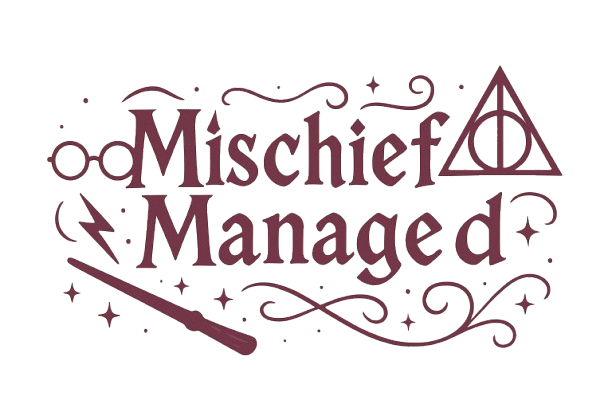